<a href="https://colab.research.google.com/github/Baelfyre/MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/blob/main/MO_IT117_Data_Visualization_Plan_MO_IT115_A3101_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MO-IT117 Data Visualization Techniques
## Group 3 Visualization Review Notebook

This version is arranged for **team review first**.

The notebook now follows this order:

1. **Visualizations**
2. **Calculations and Supporting Code**
3. **Tableau Guide Tables**
4. **Summary**

Each visualization is immediately followed by only four review points:

1. **Assessment**
2. **Advantages**
3. **Downsides**
4. **Current Assessment**

> **If rerunning the notebook from scratch:** run Section 2, **Calculations and Supporting Code**, first. Then return to Section 1 to regenerate the charts. The visual section is placed first mainly to make GitHub and team review easier.


# 1. Visualizations


## Visualization 1: Overall Internet Use by Region, Sorted Bar Chart


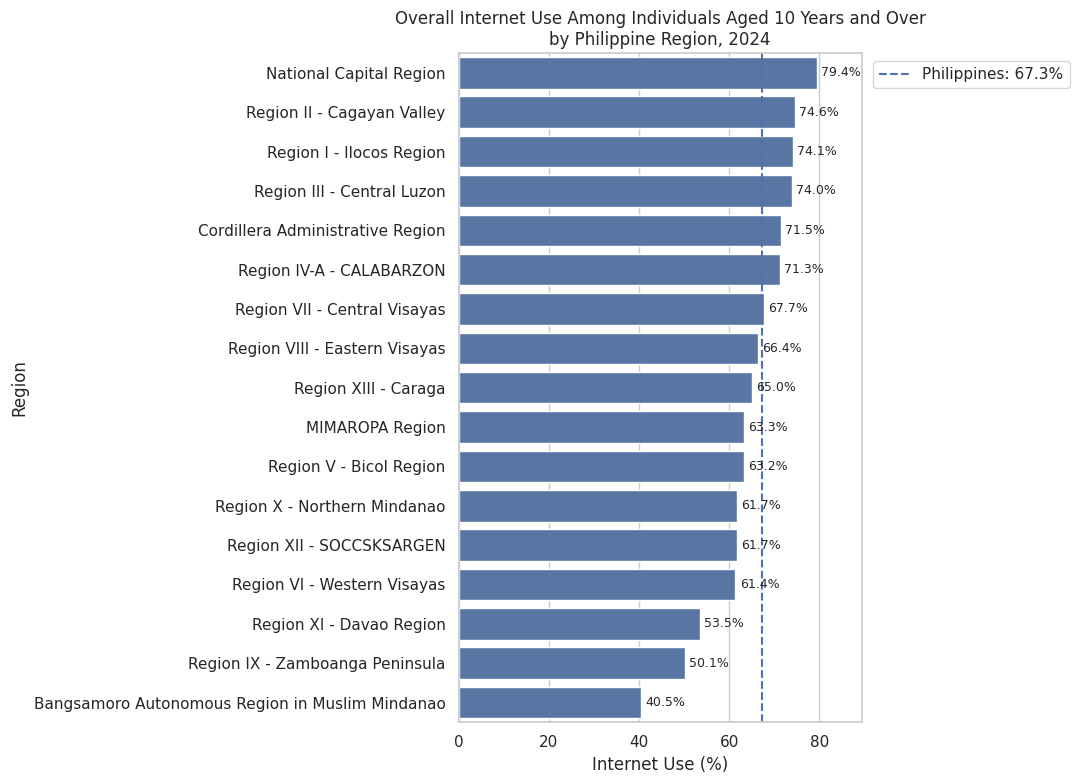

In [68]:
# @title
# ============================================================
# 11. VISUALIZE OVERALL INTERNET USE BY REGION
# ============================================================
# The chart answers:
#
# "How does overall internet use vary across Philippine regions?"
#
# A horizontal bar chart is used because the regional names are
# long and because ranking is important for this question.

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=regional_internet_use,
    x="Percentage",
    y="Region"
)

# Add the Philippine national percentage as a reference line.
# This makes it easy to see which regions fall above or below
# the national benchmark.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.5,
    label=f"Philippines: {national_percentage:.1f}%"
)

# Display the actual percentage beside every regional bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Overall Internet Use Among Individuals Aged 10 Years and Over\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Internet Use (%)")
plt.ylabel("Region")

# Place the national benchmark legend outside the plotting area
# so it does not cover the highest regional bar.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add space on the right so value labels are not cut off.
plt.xlim(
    0,
    regional_internet_use["Percentage"].max() + 10
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Useful for exact regional ranking and direct percentage comparison.

2. **Advantages**
   - Easy to compare exact values
   - Region names remain readable
   - National benchmark is easy to show

3. **Downsides**
   - Does not show geographic location
   - Less visually connected to the project's regional focus

4. **Current Assessment:** **Strong Alternative**


## Visualization 2: Overall Internet Use by Region, Philippine Choropleth


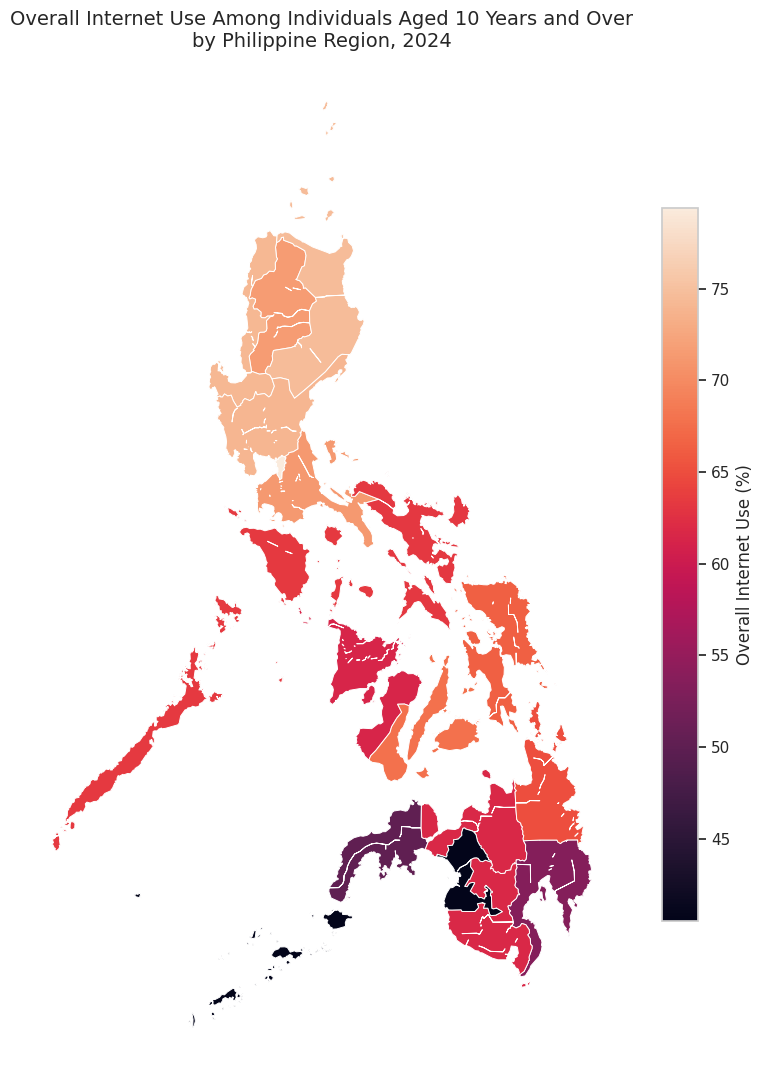

In [67]:
# @title
# ============================================================
# PHILIPPINES CHOROPLETH:
# OVERALL INTERNET USE BY REGION
# ============================================================
# The same Percentage measure used in the Q1 bar chart is mapped
# geographically.
#
# This lets us compare whether the map communicates the regional
# pattern more effectively than the ranked bar chart.

fig, ax = plt.subplots(
    figsize=(9, 11)
)

internet_map.plot(
    column="Percentage",
    ax=ax,
    legend=True,
    edgecolor="white",
    linewidth=0.7,
    legend_kwds={
        "label": "Overall Internet Use (%)",
        "shrink": 0.7
    }
)

ax.set_title(
    "Overall Internet Use Among Individuals Aged 10 Years and Over\n"
    "by Philippine Region, 2024",
    fontsize=14
)

# Geographic coordinate axes do not add useful information for
# the intended dashboard audience.
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Best current visual for the project's main geographic story.

2. **Advantages**
   - Shows where connectivity gaps appear
   - Easy to understand at a glance
   - Strong match with the regional project focus

3. **Downsides**
   - Exact ranking is harder to judge than with bars
   - Small regions can be visually less prominent

4. **Current Assessment:** **Primary Candidate**


## Visualization 3: Daily Internet Use by Region, Sorted Bar Chart


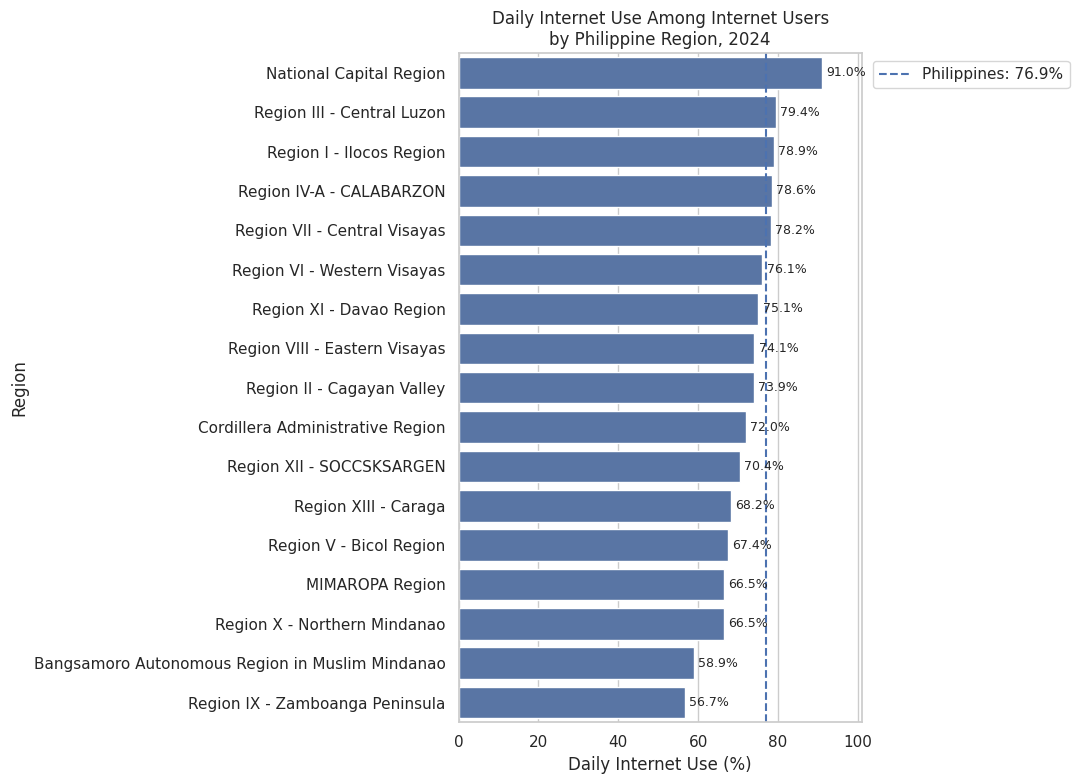

In [66]:
# @title
# ============================================================
# 16. VISUALIZE DAILY INTERNET USE BY REGION
# ============================================================

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=regional_daily_use,
    x="Percentage",
    y="Region"
)

# National daily-use benchmark.
plt.axvline(
    daily_national_percentage,
    linestyle="--",
    linewidth=1.5,
    label=f"Philippines: {daily_national_percentage:.1f}%"
)

# Display percentage values.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Daily Internet Use Among Internet Users\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Daily Internet Use (%)")
plt.ylabel("Region")

# Keep the legend away from the bars.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.xlim(
    0,
    regional_daily_use["Percentage"].max() + 10
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Clear for ranking daily-use frequency, but it overlaps with the broader reach-versus-frequency analysis.

2. **Advantages**
   - Easy to rank regions
   - Exact daily-use percentages are clear
   - Simple for general audiences

3. **Downsides**
   - Repeats the same regional comparison structure as overall internet use
   - Does not show how reach and frequency interact

4. **Current Assessment:** **Revise / Combine**


## Visualization 4: Overall Internet Use vs Daily Use, Basic Scatter Plot


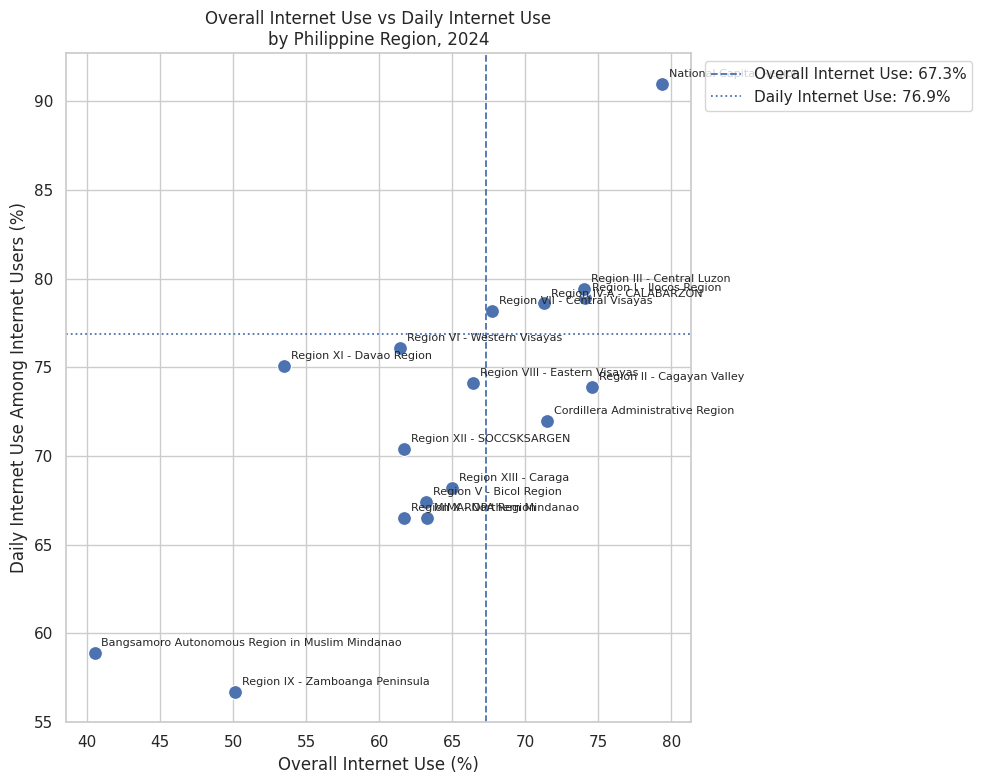

In [65]:
# @title
# ============================================================
# 21. VISUALIZE INTERNET REACH VS DAILY USE
# ============================================================

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=reach_frequency,
    x="Overall_Internet_Use",
    y="Daily_Internet_Use",
    s=100
)

# National reference lines.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.3,
    label=f"Overall Internet Use: {national_percentage:.1f}%"
)

plt.axhline(
    daily_national_percentage,
    linestyle=":",
    linewidth=1.3,
    label=f"Daily Internet Use: {daily_national_percentage:.1f}%"
)

# Label every regional point.
for _, row in reach_frequency.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Overall_Internet_Use"],
            row["Daily_Internet_Use"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(
    "Overall Internet Use vs Daily Internet Use\n"
    "by Philippine Region, 2024"
)

plt.xlabel("Overall Internet Use (%)")
plt.ylabel("Daily Internet Use Among Internet Users (%)")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Useful for checking whether internet reach and daily-use frequency move together.

2. **Advantages**
   - Shows the relationship directly
   - Makes unusual regions easier to spot
   - Simple quantitative comparison

3. **Downsides**
   - Does not show population size
   - Labels can become crowded

4. **Current Assessment:** **Exploratory Candidate**


## Visualization 5: Reach vs Daily Use, Bubble Scatter with Benchmark Quadrants


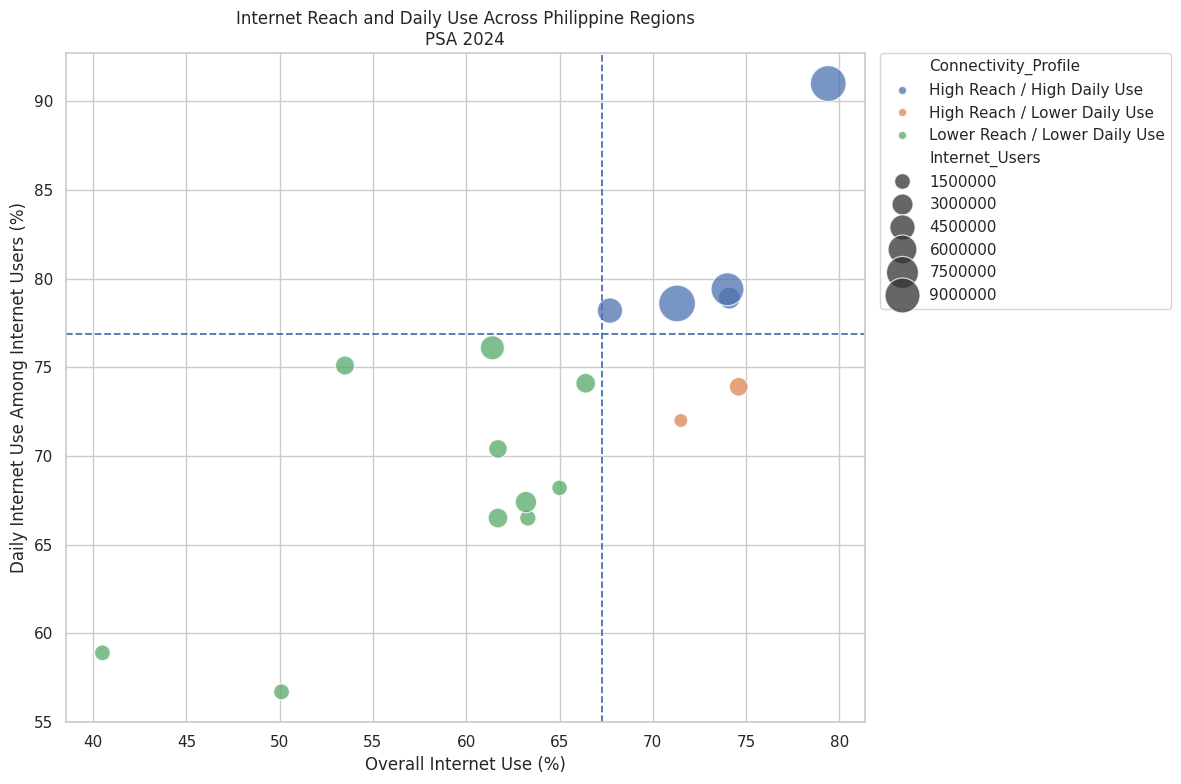

In [64]:
# @title
# ============================================================
# 26. BUBBLE SCATTER:
#     INTERNET REACH VS DAILY USE
# ============================================================
# X position:
#   Overall Internet Use %
#
# Y position:
#   Daily Internet Use %
#
# Bubble size:
#   Number of Internet Users
#
# Bubble category:
#   Connectivity Profile based on national benchmarks.
#
# Bubble size provides population context only and should not
# be interpreted as connectivity performance.

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=reach_frequency,
    x="Overall_Internet_Use",
    y="Daily_Internet_Use",
    size="Internet_Users",
    hue="Connectivity_Profile",

    # Keep the bubble-size range controlled so highly populated
    # regions do not overwhelm the visualization.
    sizes=(100, 700),

    alpha=0.75
)

# National benchmarks divide the chart into four analytical areas.
plt.axvline(
    national_percentage,
    linestyle="--",
    linewidth=1.3
)

plt.axhline(
    daily_national_percentage,
    linestyle="--",
    linewidth=1.3
)

plt.title(
    "Internet Reach and Daily Use Across Philippine Regions\n"
    "PSA 2024"
)

plt.xlabel("Overall Internet Use (%)")
plt.ylabel("Daily Internet Use Among Internet Users (%)")

# Move the legend outside the plotting area.
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Adds population context and makes regional connectivity profiles easier to compare.

2. **Advantages**
   - Combines reach, daily use, and user population
   - Quadrants make profiles easier to interpret
   - Good for spotting exceptions

3. **Downsides**
   - More complex than a standard scatter plot
   - Bubble size is less precise than position
   - Needs a clear legend and tooltip

4. **Current Assessment:** **Strong Candidate**


## Visualization 6: Working Device Access vs Internet Use, Basic Scatter Plot


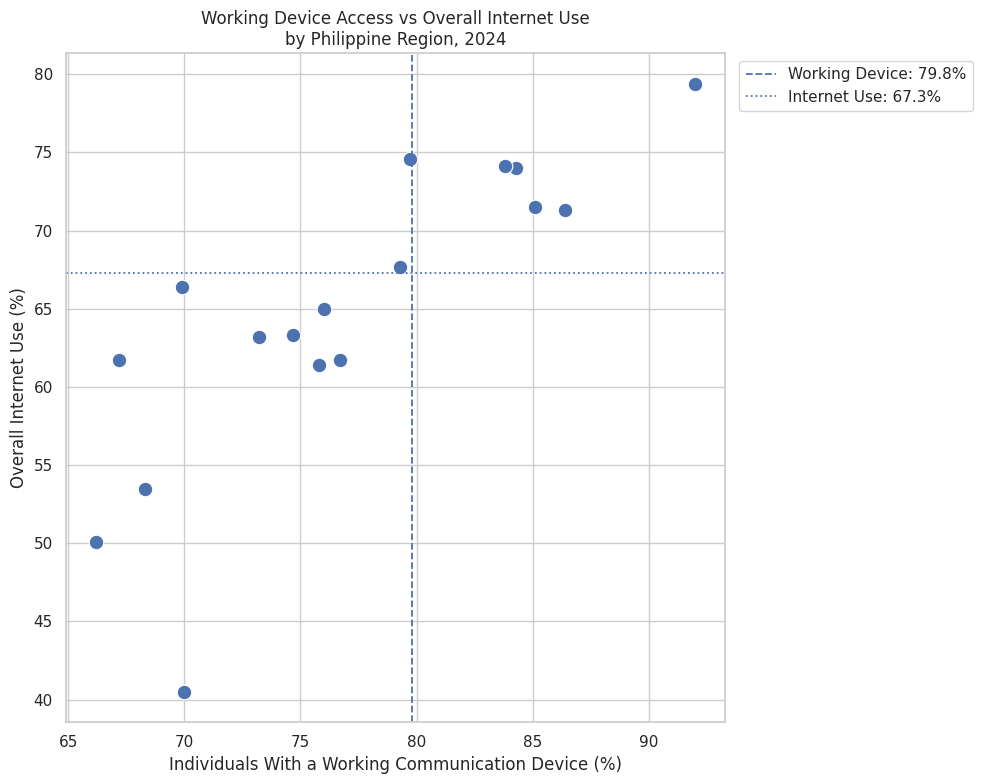

In [63]:
# @title
# ============================================================
# 31. VISUALIZE WORKING-DEVICE ACCESS VS INTERNET USE
# ============================================================

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=device_internet,
    x="Working_Device_Percentage",
    y="Overall_Internet_Use",
    s=110
)

# National device benchmark.
plt.axvline(
    working_device_national_percentage,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"Working Device: "
        f"{working_device_national_percentage:.1f}%"
    )
)

# National internet-use benchmark.
plt.axhline(
    national_percentage,
    linestyle=":",
    linewidth=1.3,
    label=(
        f"Internet Use: "
        f"{national_percentage:.1f}%"
    )
)

plt.title(
    "Working Device Access vs Overall Internet Use\n"
    "by Philippine Region, 2024"
)

plt.xlabel(
    "Individuals With a Working Communication Device (%)"
)

plt.ylabel(
    "Overall Internet Use (%)"
)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Shows the positive regional relationship between working-device access and overall internet use.

2. **Advantages**
   - Easy relationship to understand
   - Adds infrastructure context
   - Supports regional comparison

3. **Downsides**
   - Similar to other scatter plots
   - Working device does not automatically mean internet-capable device

4. **Current Assessment:** **Supporting Candidate / Review**


## Visualization 7: Working Device Access vs Internet Use, Trend-Line Scatter


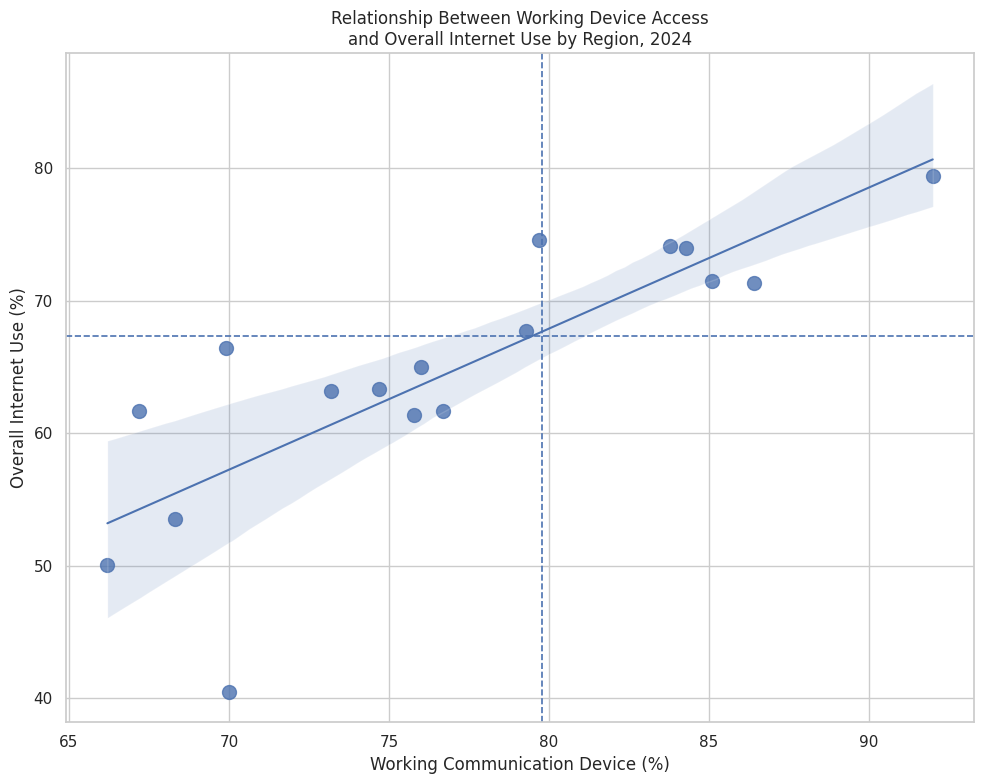

In [62]:
# @title
# ============================================================
# 33. ADD AN EXPLORATORY TREND LINE
# ============================================================
# The regression line helps us inspect the overall direction
# of the regional relationship.
#
# It should not be interpreted as evidence that device access
# causes internet use.

plt.figure(figsize=(10, 8))

sns.regplot(
    data=device_internet,
    x="Working_Device_Percentage",
    y="Overall_Internet_Use",
    scatter_kws={
        "s": 100,
        "alpha": 0.8
    },
    line_kws={
        "linewidth": 1.5
    }
)

plt.axvline(
    working_device_national_percentage,
    linestyle="--",
    linewidth=1.2
)

plt.axhline(
    national_percentage,
    linestyle="--",
    linewidth=1.2
)

plt.title(
    "Relationship Between Working Device Access\n"
    "and Overall Internet Use by Region, 2024"
)

plt.xlabel(
    "Working Communication Device (%)"
)

plt.ylabel(
    "Overall Internet Use (%)"
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Adds a trend line to make the overall direction of the device-internet relationship easier to see.

2. **Advantages**
   - Direction of the relationship is immediately visible
   - Useful for explaining the positive association
   - Retains region-level detail

3. **Downsides**
   - Trend line can look more conclusive than the evidence supports
   - Still visually similar to the reach-versus-frequency scatter

4. **Current Assessment:** **Supporting Candidate / Review**


## Visualization 8: Regional Network-Signal Heatmap


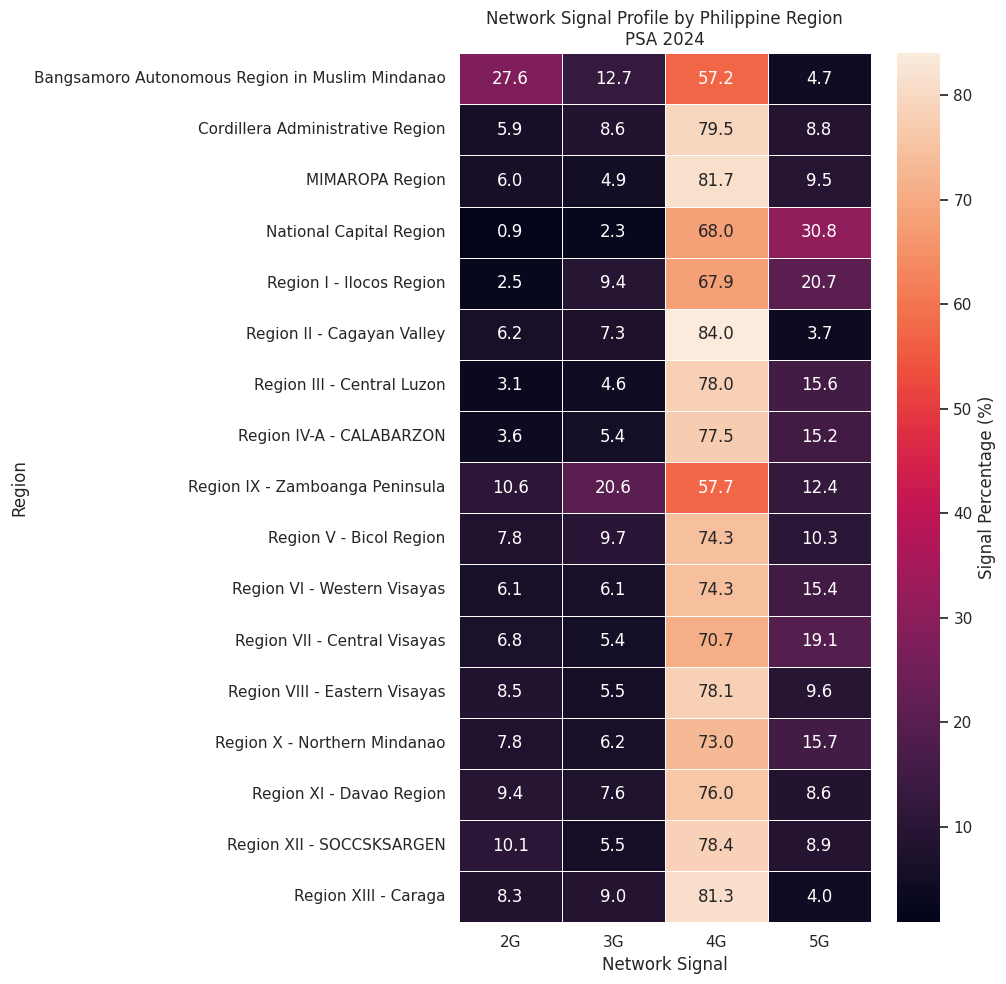

In [60]:
# @title
# ============================================================
# 39. BOXED REGIONAL NETWORK-SIGNAL HEATMAP
# ============================================================
# annot=True:
#   displays the actual percentage inside each box.
#
# linewidths:
#   creates visible boundaries between cells, giving the
#   visualization the boxed-table appearance.
#
# fmt=".1f":
#   formats each value to one decimal place.

plt.figure(figsize=(10, 10))

ax = sns.heatmap(
    signal_matrix,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Signal Percentage (%)"
    }
)

plt.title(
    "Network Signal Profile by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Network Signal")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Compact comparison of 2G, 3G, 4G, and 5G percentages across all 17 regions.

2. **Advantages**
   - Shows several network indicators in one view
   - Regional differences are easy to scan
   - Adds visual variety

3. **Downsides**
   - More complex than a bar chart
   - Color comparison is less precise than bar length
   - Needs a short explanation for general audiences

4. **Current Assessment:** **Strong Supporting Candidate**


## Visualization 9: Network-Signal Correlation Heatmap


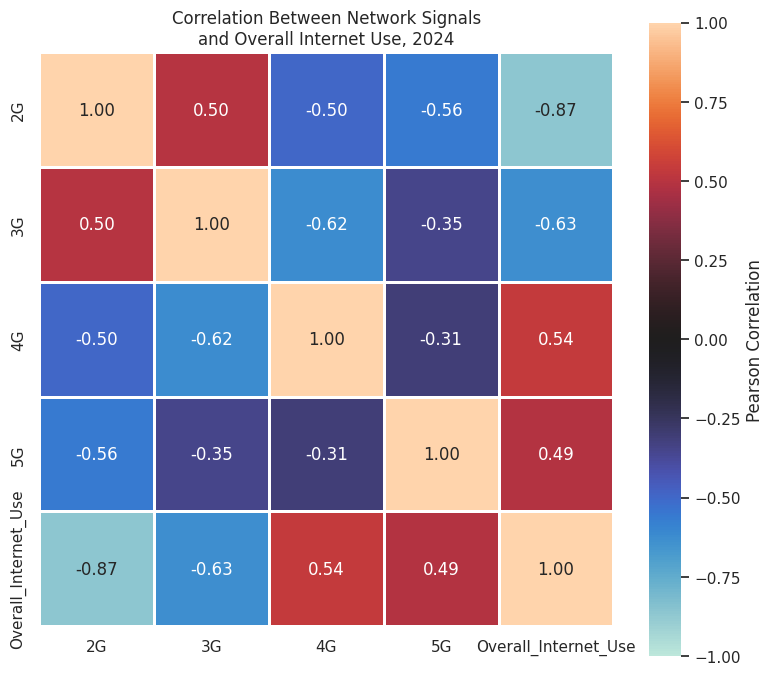

In [61]:
# @title
# ============================================================
# 44. BOXED CORRELATION HEATMAP
# ============================================================
# Values range from -1 to +1:
#
# +1 = strong positive relationship
#  0 = little linear relationship
# -1 = strong negative relationship

plt.figure(figsize=(8, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Correlation Between Network Signals\n"
    "and Overall Internet Use, 2024"
)

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Useful as a diagnostic view for checking how signal measures relate to each other and to internet use.

2. **Advantages**
   - Summarizes several relationships at once
   - Good for identifying which relationships deserve closer inspection
   - Compact diagnostic view

3. **Downsides**
   - Correlation is not causation
   - Harder for general audiences to interpret
   - Not necessary for the final dashboard

4. **Current Assessment:** **Diagnostic Only**


## Visualization 10: Network Signals vs Internet Use, Four Scatter Comparisons


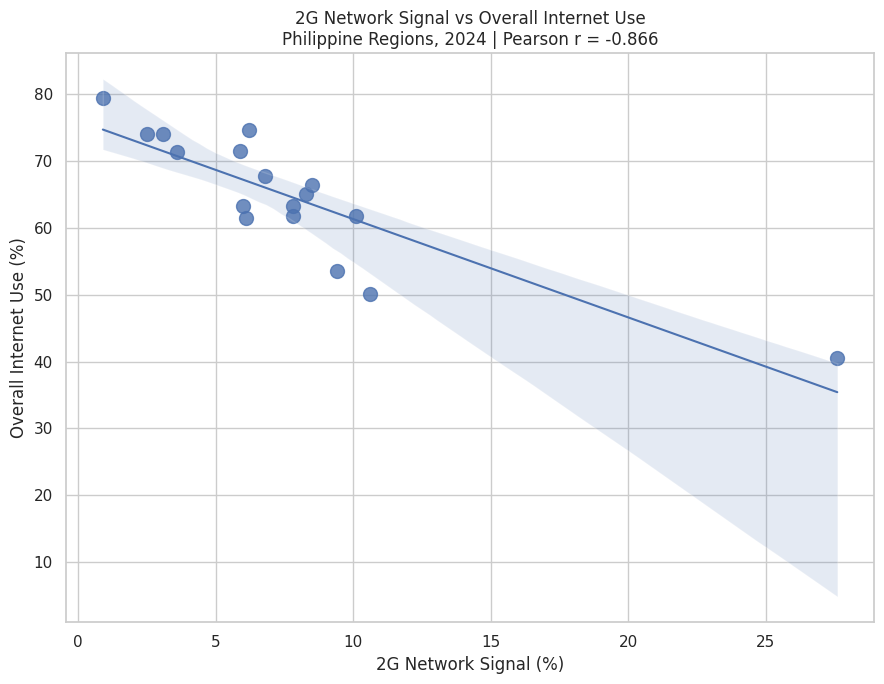

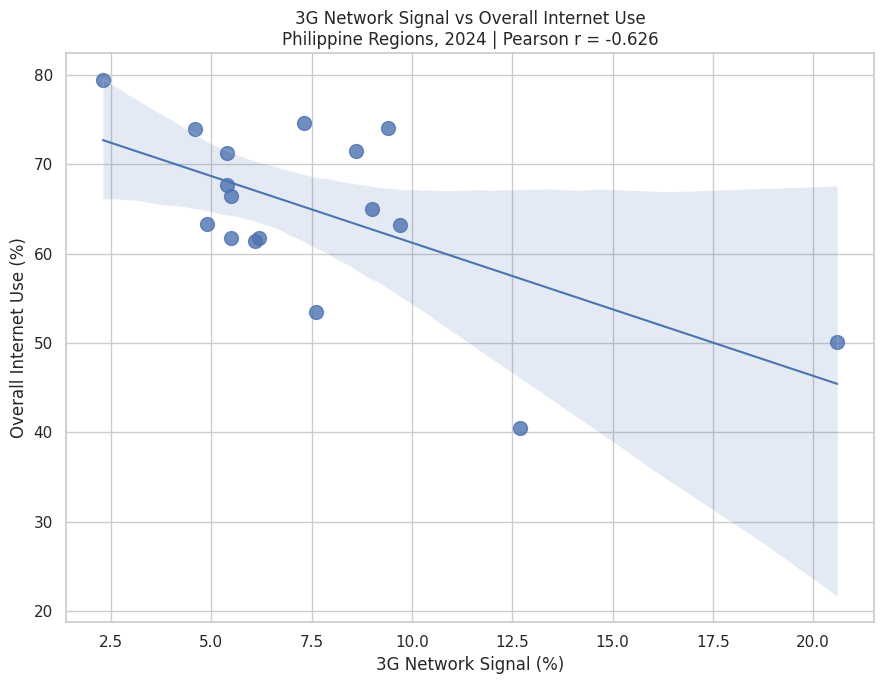

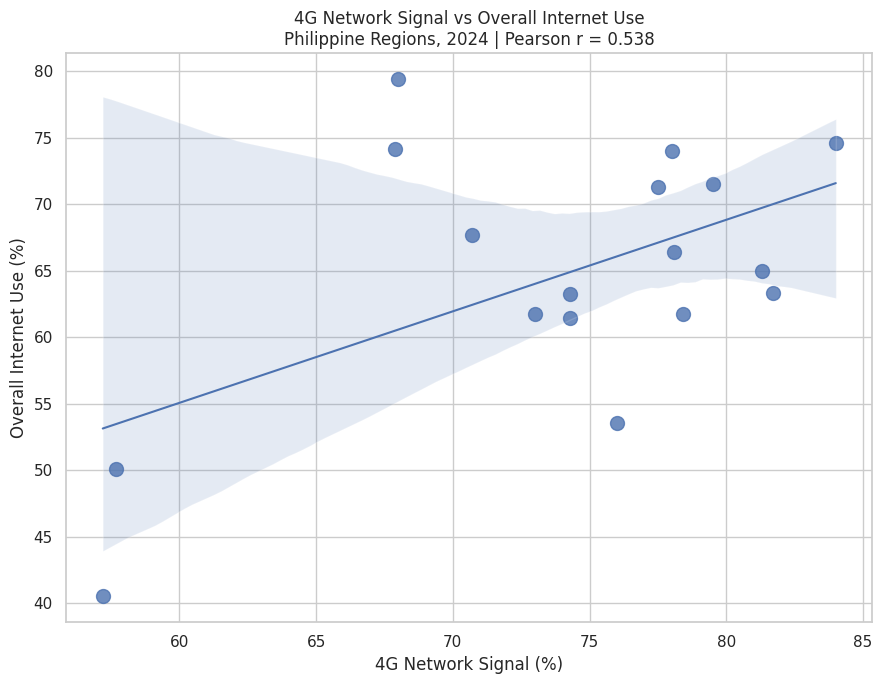

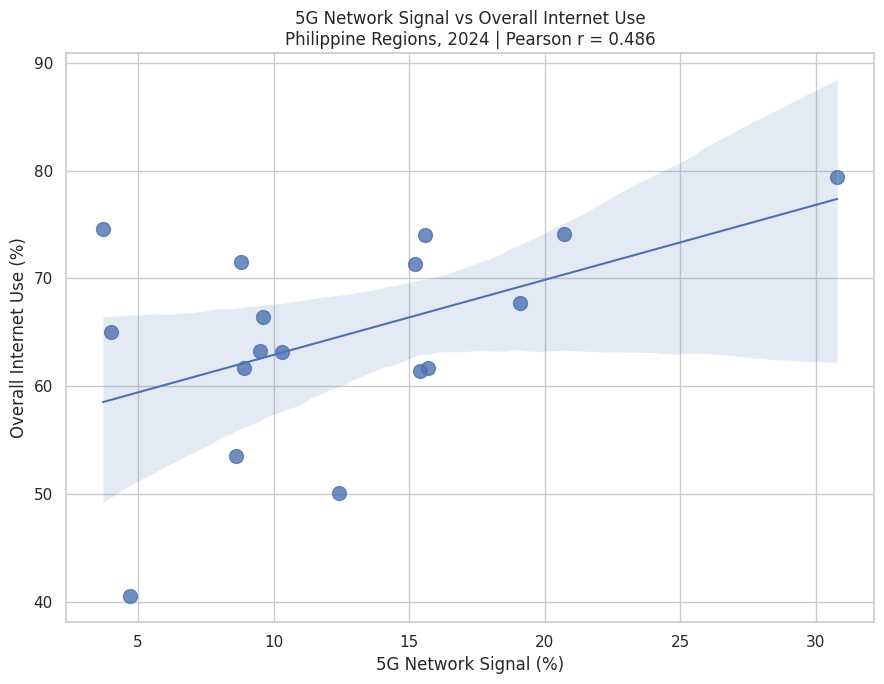

In [59]:
# @title
# ============================================================
# 46. SCATTER PLOTS WITH CORRELATION VALUES
# ============================================================

for signal in signal_categories:

    # Calculate correlation for the current signal.
    r = signal_internet[
        [signal, "Overall_Internet_Use"]
    ].corr().iloc[0, 1]

    plt.figure(figsize=(9, 7))

    sns.regplot(
        data=signal_internet,
        x=signal,
        y="Overall_Internet_Use",
        scatter_kws={
            "s": 100,
            "alpha": 0.8
        },
        line_kws={
            "linewidth": 1.5
        }
    )

    plt.title(
        f"{signal} Network Signal vs Overall Internet Use\n"
        f"Philippine Regions, 2024 | Pearson r = {r:.3f}"
    )

    plt.xlabel(
        f"{signal} Network Signal (%)"
    )

    plt.ylabel(
        "Overall Internet Use (%)"
    )

    plt.tight_layout()
    plt.show()

### Analysis of the chart

1. **Assessment:** Compares each signal category with overall internet use to identify which relationships appear strongest.

2. **Advantages**
   - Lets the team compare 2G, 3G, 4G, and 5G consistently
   - Useful for selecting a focused relationship
   - Shows exceptions and spread

3. **Downsides**
   - Produces several similar charts
   - Too much for a final dashboard
   - Mainly useful during exploration

4. **Current Assessment:** **Diagnostic Only**


## Visualization 11: 2G Signal vs Overall Internet Use


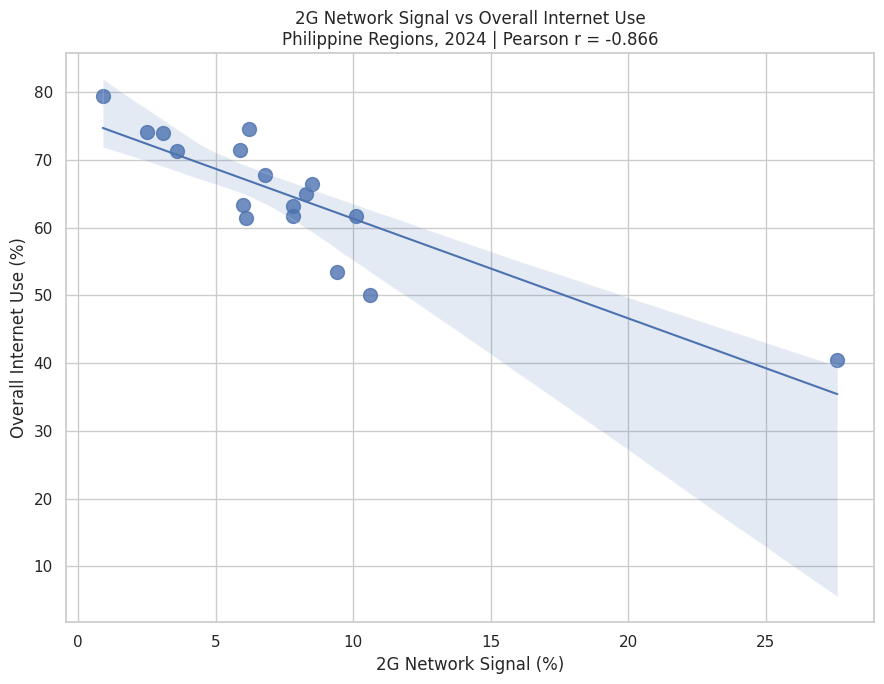

In [58]:
# @title
# ============================================================
# 47. FOCUSED SCATTER:
#     2G NETWORK SIGNAL VS OVERALL INTERNET USE
# ============================================================
# 2G produced the strongest absolute correlation with overall
# internet use among the four network-signal categories.
#
# The purpose of this chart is therefore to examine that
# relationship more closely.

signal_2g_correlation = (
    signal_internet[
        ["2G", "Overall_Internet_Use"]
    ]
    .corr()
    .iloc[0, 1]
)

plt.figure(figsize=(9, 7))

sns.regplot(
    data=signal_internet,
    x="2G",
    y="Overall_Internet_Use",
    scatter_kws={
        "s": 100,
        "alpha": 0.8
    },
    line_kws={
        "linewidth": 1.5
    }
)

plt.title(
    "2G Network Signal vs Overall Internet Use\n"
    f"Philippine Regions, 2024 | Pearson r = {signal_2g_correlation:.3f}"
)

plt.xlabel("2G Network Signal (%)")
plt.ylabel("Overall Internet Use (%)")

plt.tight_layout()
plt.show()

### Analysis of the chart

1. **Assessment:** Focused supporting view because 2G shows the strongest absolute relationship with overall internet use among the signal categories.

2. **Advantages**
   - Clear downward relationship
   - Easy to explain
   - Helps identify regions with heavier older-network presence

3. **Downsides**
   - Shows only one signal category
   - Adds another scatter plot
   - Correlation does not prove causation

4. **Current Assessment:** **Exploratory / Supporting Evidence**


## Visualization 12: National Internet Activities, Word Cloud


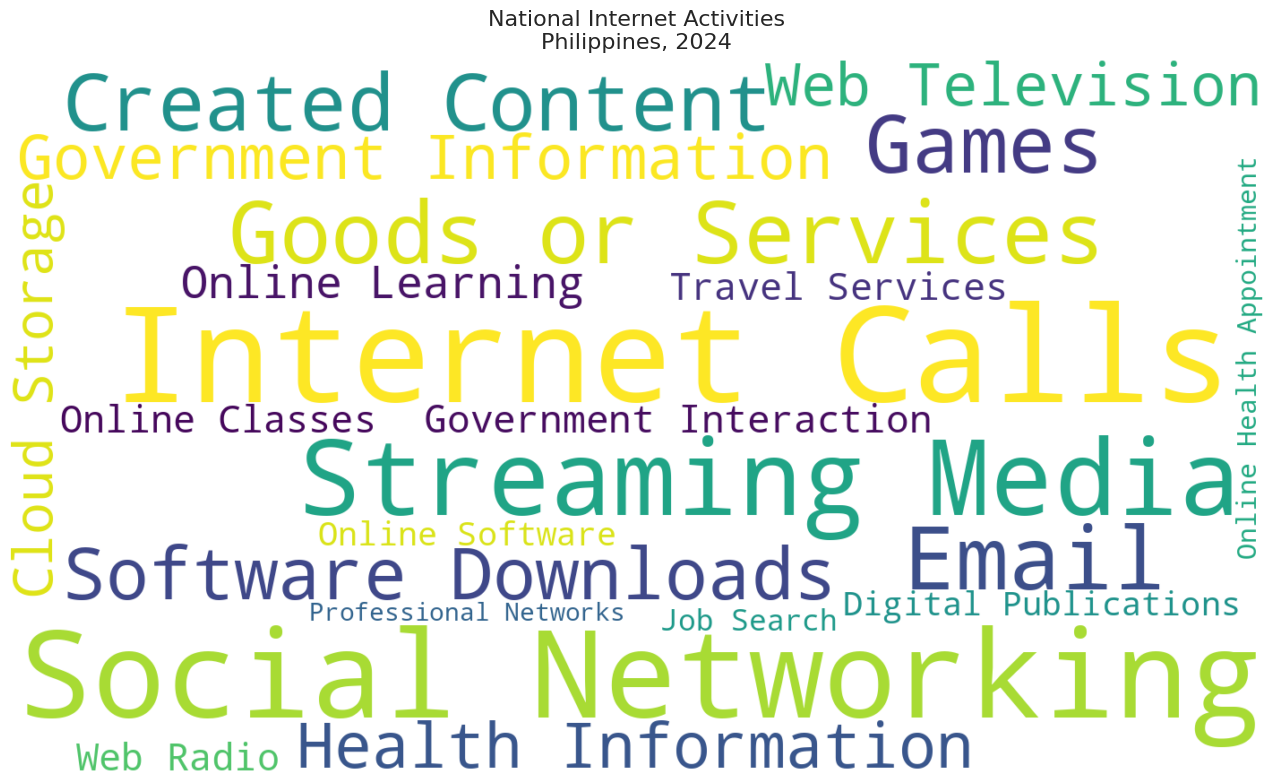

In [48]:
# @title
# ============================================================
# CANDIDATE 1: NATIONAL INTERNET-ACTIVITY WORD CLOUD
# ============================================================
# Font size represents the national percentage of each activity.
# This is exploratory and is not intended for precise comparison.

!pip -q install wordcloud

from wordcloud import WordCloud

activity_frequencies = dict(
    zip(
        national_activity["Internet Activity"],
        national_activity["Percentage"]
    )
)

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    prefer_horizontal=0.9,
    collocations=False
).generate_from_frequencies(
    activity_frequencies
)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("National Internet Activities\nPhilippines, 2024", fontsize=16)
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Provides a quick visual impression of which internet activities are most prominent nationally.

2. **Advantages**
   - Fast visual overview
   - Compact and engaging
   - Makes high-percentage activities stand out

3. **Downsides**
   - Poor for exact comparison
   - Ranking is not precise
   - Does not show regional differences

4. **Current Assessment:** **Exploratory Candidate**


## Visualization 13: National Internet Activities, Sorted Horizontal Bar


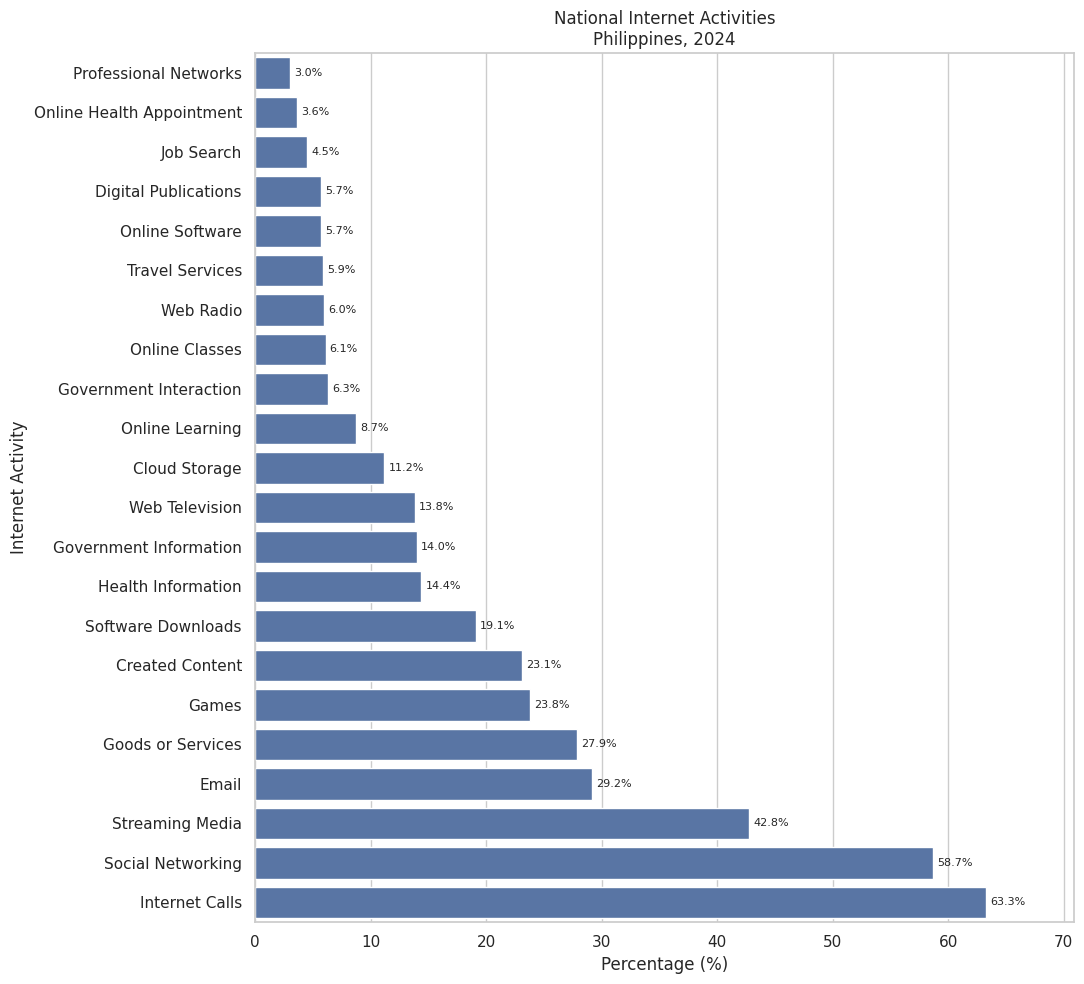

In [57]:
# @title
# ============================================================
# CANDIDATE 2: SORTED NATIONAL INTERNET-ACTIVITY BAR CHART
# ============================================================
# Same data as the word cloud, allowing a fair visual comparison.

activity_bar = (
    national_activity
    .sort_values("Percentage", ascending=True)
    .copy()
)

plt.figure(figsize=(11, 10))

ax = sns.barplot(
    data=activity_bar,
    y="Internet Activity",
    x="Percentage"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.title("National Internet Activities\nPhilippines, 2024")
plt.xlabel("Percentage (%)")
plt.ylabel("Internet Activity")
plt.xlim(0, activity_bar["Percentage"].max() * 1.12)
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Provides a more precise national ranking of internet activities than the word cloud.

2. **Advantages**
   - Clear ranking
   - Exact percentages are easy to compare
   - Long activity labels remain readable

3. **Downsides**
   - Uses more vertical space
   - Shows national activity only
   - Can feel dense with all 22 categories

4. **Current Assessment:** **Strong Exploratory Candidate**


## Visualization 14: Regional Internet-Activity Heatmap


ACTIVITIES INCLUDED IN THE HEATMAP
------------------------------------------------------------
- Internet Calls
- Social Networking
- Email
- Streaming Media
- Goods or Services
- Games
- Health Information
- Web Television

HEATMAP VALIDATION
------------------------------------------------------------
Regions: 17
Activities: 8
Missing values: 0


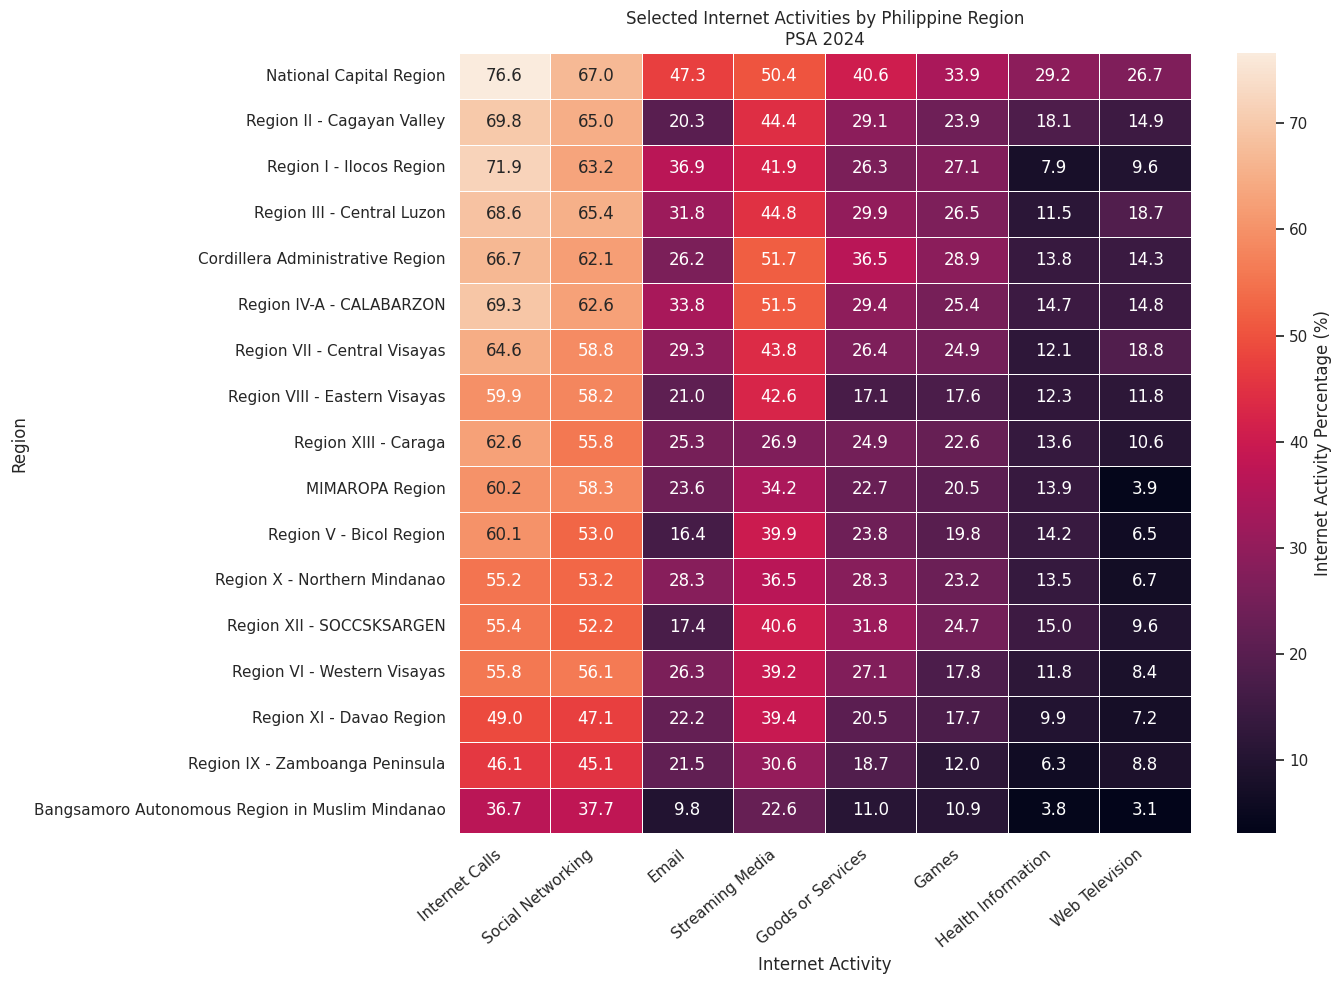

In [56]:
# @title
# ============================================================
# CANDIDATE 3: REGIONAL INTERNET-ACTIVITY HEATMAP
# ============================================================

top_8_activity_candidates = (
    activity_priority
    .head(8)["Internet Activity"]
    .tolist()
)

print("ACTIVITIES INCLUDED IN THE HEATMAP")
print("-" * 60)

for activity in top_8_activity_candidates:
    print(f"- {activity}")

activity_heatmap_top8 = (
    regional_activity[
        regional_activity["Internet Activity"]
        .isin(top_8_activity_candidates)
    ]
    .pivot(
        index="Region",
        columns="Internet Activity",
        values="Percentage"
    )
)

# Preserve exploratory priority order.
activity_heatmap_top8 = activity_heatmap_top8[
    top_8_activity_candidates
]

# Sort regions by overall internet-use percentage.
region_order = (
    regional_internet_use
    .sort_values("Percentage", ascending=False)["Region"]
    .tolist()
)

activity_heatmap_top8 = activity_heatmap_top8.reindex(region_order)

print()
print("HEATMAP VALIDATION")
print("-" * 60)
print(f"Regions: {activity_heatmap_top8.shape[0]}")
print(f"Activities: {activity_heatmap_top8.shape[1]}")
print(f"Missing values: {activity_heatmap_top8.isna().sum().sum()}")

plt.figure(figsize=(14, 10))

sns.heatmap(
    activity_heatmap_top8,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Internet Activity Percentage (%)"}
)

plt.title("Selected Internet Activities by Philippine Region\nPSA 2024")
plt.xlabel("Internet Activity")
plt.ylabel("Region")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Compares selected internet activities across all 17 regions in one view.

2. **Advantages**
   - Shows activity and regional differences together
   - Makes unusual regional patterns visible
   - Exact values can stay inside cells

3. **Downsides**
   - More complex than the other activity options
   - Too many activities reduce readability
   - Requires a justified activity shortlist

4. **Current Assessment:** **Strong Supporting Candidate**


## Visualization 15: National Age-Profile Bar Chart


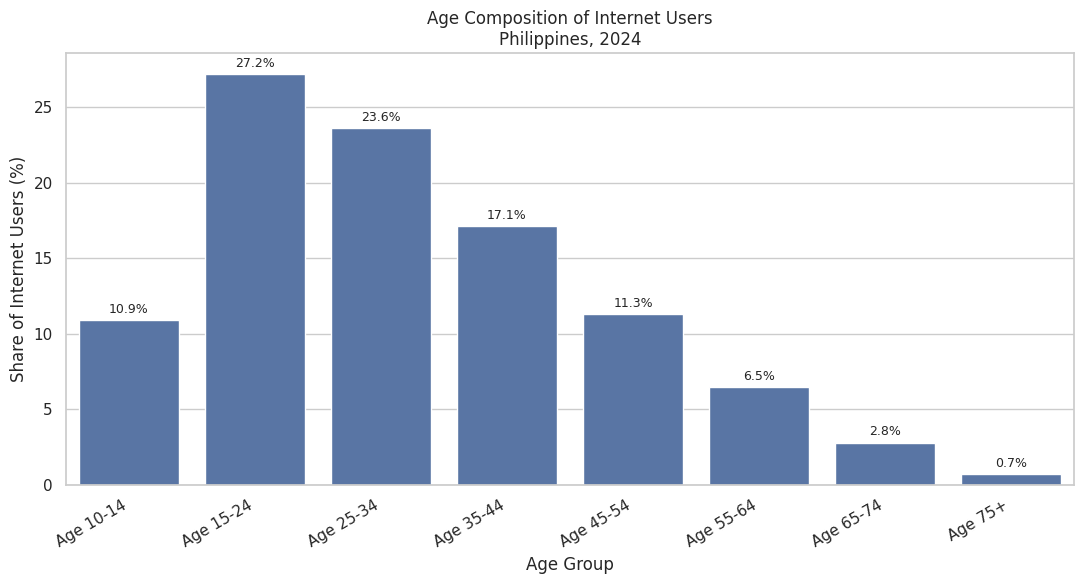

In [55]:
# @title
# ============================================================
# AGE CANDIDATE 1:
# NATIONAL AGE-PROFILE BAR CHART
# ============================================================

age_chart = national_age[
    national_age["Age Group"] != "Not Reported"
].copy()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=age_chart,
    x="Age Group",
    y="Percentage",
    order=[
        "Age 10-14",
        "Age 15-24",
        "Age 25-34",
        "Age 35-44",
        "Age 45-54",
        "Age 55-64",
        "Age 65-74",
        "Age 75+"
    ]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "Age Composition of Internet Users\n"
    "Philippines, 2024"
)

plt.xlabel("Age Group")
plt.ylabel("Share of Internet Users (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Shows which age groups make up the largest shares of recorded internet users nationally.

2. **Advantages**
   - Natural age order is easy to follow
   - Largest and smallest groups are clear
   - Simple for general audiences

3. **Downsides**
   - National view only
   - Does not show regional differences
   - Shows composition, not age-specific internet penetration

4. **Current Assessment:** **Strong Exploratory Candidate**


## Visualization 16: Regional Age-Group Heatmap


AGE HEATMAP VALIDATION
------------------------------------------------------------
Regions: 17
Age groups: 8
Missing values: 0


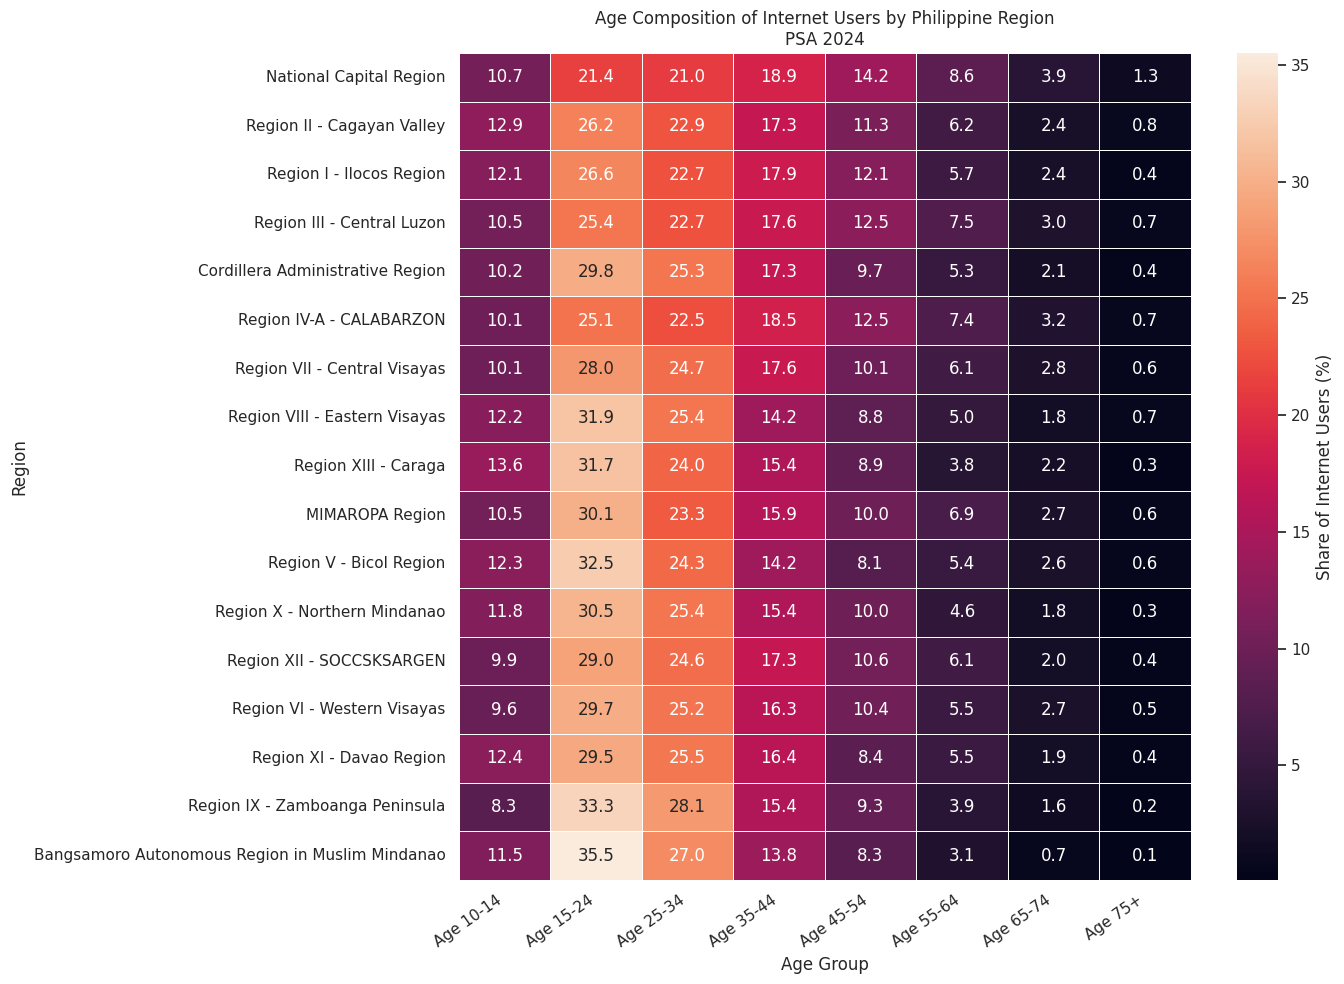

In [54]:
# @title
# ============================================================
# AGE CANDIDATE 2:
# REGIONAL AGE-GROUP HEATMAP
# ============================================================

age_heatmap_order = [
    "Age 10-14",
    "Age 15-24",
    "Age 25-34",
    "Age 35-44",
    "Age 45-54",
    "Age 55-64",
    "Age 65-74",
    "Age 75+"
]

age_heatmap = (
    regional_age[
        regional_age["Age Group"].isin(age_heatmap_order)
    ]
    .pivot(
        index="Region",
        columns="Age Group",
        values="Percentage"
    )
)

age_heatmap = age_heatmap[age_heatmap_order]

# Reuse the regional order from the overall internet-use analysis.
region_order = (
    regional_internet_use
    .sort_values("Percentage", ascending=False)["Region"]
    .tolist()
)

age_heatmap = age_heatmap.reindex(region_order)

print("AGE HEATMAP VALIDATION")
print("-" * 60)
print(f"Regions: {age_heatmap.shape[0]}")
print(f"Age groups: {age_heatmap.shape[1]}")
print(f"Missing values: {age_heatmap.isna().sum().sum()}")

plt.figure(figsize=(14, 10))

sns.heatmap(
    age_heatmap,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Share of Internet Users (%)"
    }
)

plt.title(
    "Age Composition of Internet Users by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Age Group")
plt.ylabel("Region")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Shows how the age composition of recorded internet users differs across regions.

2. **Advantages**
   - Combines age and regional patterns
   - Easy to spot different age profiles
   - Exact values can be displayed

3. **Downsides**
   - More complex than the national bar chart
   - Requires more dashboard space
   - Still shows composition, not age-specific penetration

4. **Current Assessment:** **Strong Supporting Candidate**


## Visualization 17: Full Internet-Use Frequency, 100% Stacked Bar


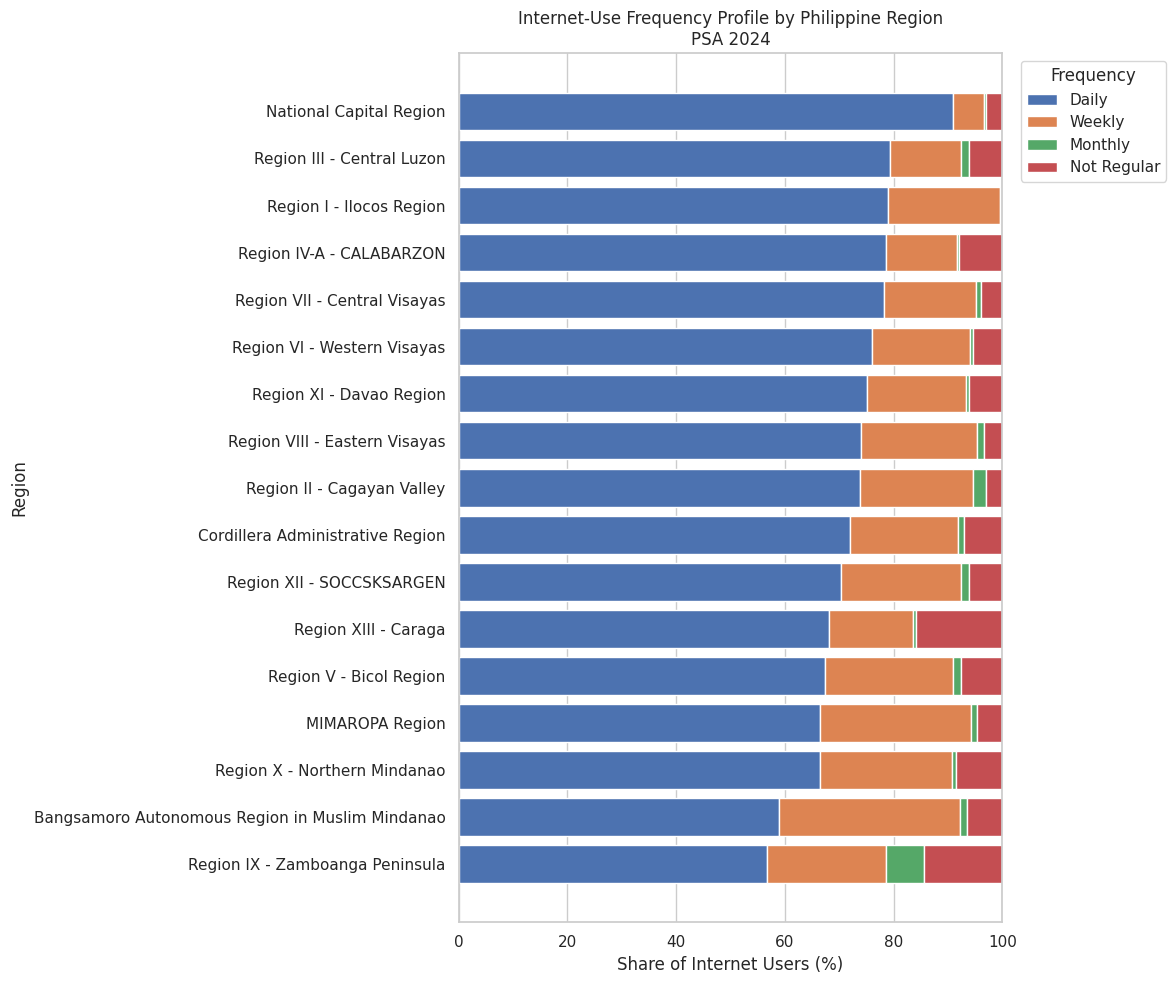

In [53]:
# @title
# ============================================================
# FREQUENCY CANDIDATE 1:
# 100% STACKED HORIZONTAL BAR CHART
# ============================================================
# Matplotlib is used here because stacked bars are not directly
# supported by Seaborn's standard barplot function.

frequency_matrix = (
    regional_frequency_profile
    .pivot(
        index="Region",
        columns="Frequency",
        values="Percentage"
    )
    [frequency_order]
)

# Sort regions by Daily share from highest to lowest.
frequency_matrix = (
    frequency_matrix
    .sort_values("Daily", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 10))

left = np.zeros(len(frequency_matrix))

for category in frequency_order:
    values = frequency_matrix[category].values

    ax.barh(
        frequency_matrix.index,
        values,
        left=left,
        label=category
    )

    left += values

ax.set_xlim(0, 100)

ax.set_title(
    "Internet-Use Frequency Profile by Philippine Region\n"
    "PSA 2024"
)

ax.set_xlabel("Share of Internet Users (%)")
ax.set_ylabel("Region")

ax.legend(
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Shows the complete balance of Daily, Weekly, Monthly, and Not Regular use for each region.

2. **Advantages**
   - Shows full frequency composition
   - Easy to compare frequent and less-frequent use
   - Adds context beyond Daily use alone

3. **Downsides**
   - Small segments are hard to compare precisely
   - Seventeen stacked bars can feel dense
   - Exact values need labels or tooltips

4. **Current Assessment:** **Strong Exploratory Candidate**


## Visualization 18: Regional Internet-Use Frequency Heatmap


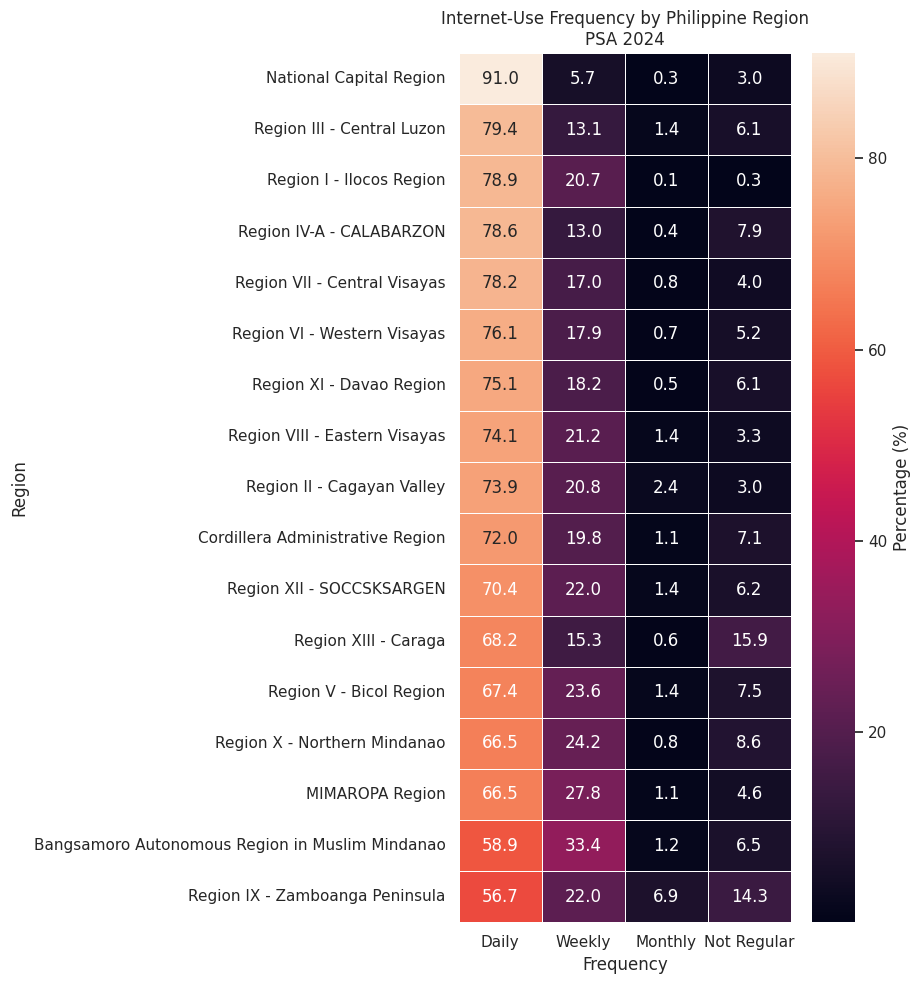

In [52]:
# @title
# ============================================================
# FREQUENCY CANDIDATE 2:
# REGIONAL FREQUENCY HEATMAP
# ============================================================

frequency_heatmap = (
    regional_frequency_profile
    .pivot(
        index="Region",
        columns="Frequency",
        values="Percentage"
    )
    [frequency_order]
)

# Sort regions by Daily use from highest to lowest.
frequency_heatmap = (
    frequency_heatmap
    .sort_values("Daily", ascending=False)
)

plt.figure(figsize=(9, 10))

sns.heatmap(
    frequency_heatmap,
    annot=True,
    fmt=".1f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Percentage (%)"
    }
)

plt.title(
    "Internet-Use Frequency by Philippine Region\n"
    "PSA 2024"
)

plt.xlabel("Frequency")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Provides a compact view of exact frequency-category differences across regions.

2. **Advantages**
   - Exact regional differences are easier to scan
   - Compact with only four columns
   - Good alternative to Daily-only ranking

3. **Downsides**
   - Part-to-whole composition is less obvious
   - Adds another heatmap
   - Depends on color for pattern recognition

4. **Current Assessment:** **Strong Supporting Candidate**


## Visualization 19: Gender Composition, Diverging Bar


/tmp/ipykernel_875/219449651.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


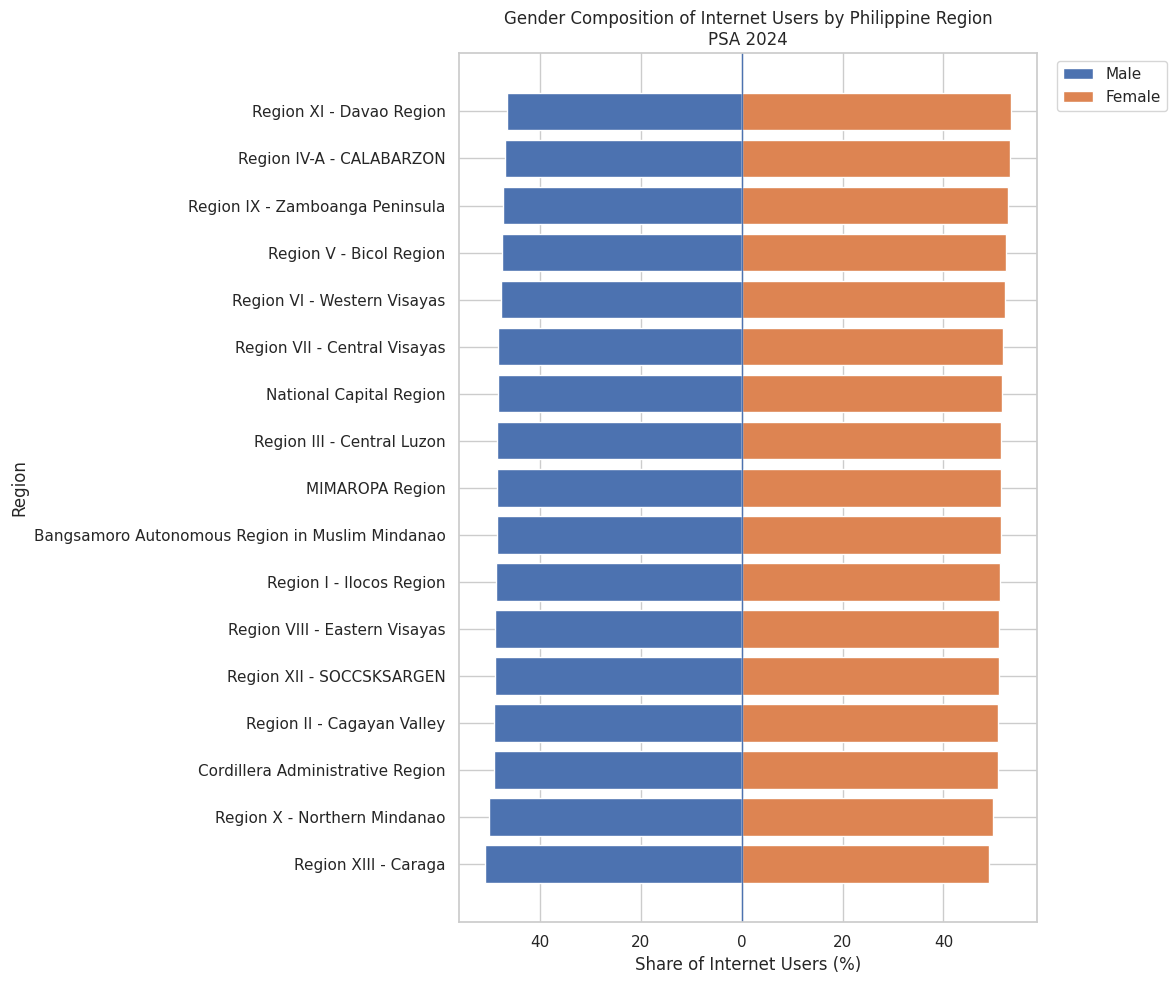

In [50]:
# @title
# ============================================================
# GENDER CANDIDATE 1:
# DIVERGING COMPOSITION BAR CHART
# ============================================================

regional_gender = (
    gender_profile[
        gender_profile["Region"] != "PHILIPPINES"
    ]
    .pivot(
        index="Region",
        columns="Gender",
        values="Percentage"
    )
)

# Sort by Female share for a consistent comparison.
regional_gender = (
    regional_gender
    .sort_values("Female", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    regional_gender.index,
    -regional_gender["Male"],
    label="Male"
)

ax.barh(
    regional_gender.index,
    regional_gender["Female"],
    label="Female"
)

ax.axvline(0, linewidth=1)

# Display absolute percentage values on both sides of the axis.
ticks = ax.get_xticks()
ax.set_xticklabels(
    [f"{abs(tick):.0f}" for tick in ticks]
)

ax.set_title(
    "Gender Composition of Internet Users by Philippine Region\n"
    "PSA 2024"
)

ax.set_xlabel("Share of Internet Users (%)")
ax.set_ylabel("Region")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


### Analysis of the chart

1. **Assessment:** Shows Female and Male shares on opposite sides so regional balance can be inspected quickly.

2. **Advantages**
   - Female and Male shares are compared directly
   - Regional balance is easy to inspect
   - Small differences are more visible

3. **Downsides**
   - Negative direction is only a layout technique
   - Needs a short explanation
   - May not deserve dashboard space if differences are small

4. **Current Assessment:** **Exploratory Candidate**


## Visualization 20: Female-Male Percentage-Point Gap


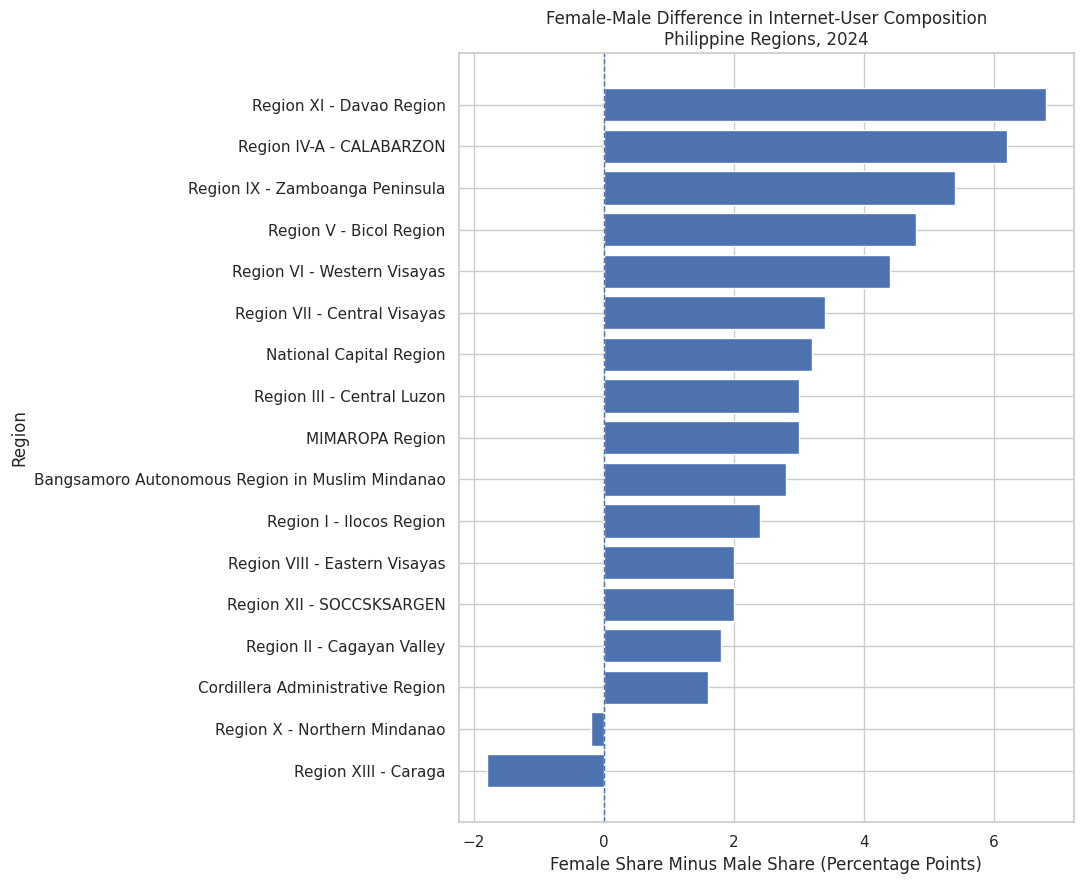

GENDER GAP SUMMARY
------------------------------------------------------------
Largest Female-leading gap: 6.8 percentage points
Largest Male-leading gap: -1.8 percentage points


In [51]:
# @title
# ============================================================
# GENDER CANDIDATE 2:
# FEMALE - MALE PERCENTAGE-POINT GAP
# ============================================================

gender_gap = regional_gender.copy()

gender_gap["Female_Male_Gap"] = (
    gender_gap["Female"]
    - gender_gap["Male"]
)

gender_gap = (
    gender_gap
    .sort_values("Female_Male_Gap")
)

fig, ax = plt.subplots(figsize=(11, 9))

ax.barh(
    gender_gap.index,
    gender_gap["Female_Male_Gap"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Female-Male Difference in Internet-User Composition\n"
    "Philippine Regions, 2024"
)

ax.set_xlabel(
    "Female Share Minus Male Share "
    "(Percentage Points)"
)

ax.set_ylabel("Region")

plt.tight_layout()
plt.show()

print("GENDER GAP SUMMARY")
print("-" * 60)
print(
    f"Largest Female-leading gap: "
    f"{gender_gap['Female_Male_Gap'].max():.1f} percentage points"
)
print(
    f"Largest Male-leading gap: "
    f"{gender_gap['Female_Male_Gap'].min():.1f} percentage points"
)


### Analysis of the chart

1. **Assessment:** Reduces gender composition to a single regional difference measure for easier comparison.

2. **Advantages**
   - Makes size and direction of the difference clear
   - Easy to identify the largest gaps
   - More compact than showing both shares

3. **Downsides**
   - Hides the original percentages
   - Uses a calculated difference
   - Should not be read as gender-specific internet penetration

4. **Current Assessment:** **Diagnostic / Exploratory Candidate**


# 2. Calculations and Supporting Code

This section contains the **non-visualization code** used to load, validate, prepare, combine, and summarize the data.

It is separated from the chart review so teammates can focus on the visual outputs first.

> Run this section first when recomputing the notebook from scratch.


## 2.1 Setup, Data Sources, and Validation


In [3]:
# @title
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
# pandas:
#   Used for loading, filtering, combining, and inspecting data.
#
# numpy:
#   Used for numerical operations when needed.
#
# matplotlib:
#   Provides the base plotting system used by Seaborn.
#
# seaborn:
#   Used for exploratory visualizations that will help us decide
#   which charts and data relationships should later be built
#   in Tableau.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve how tables are displayed inside Google Colab.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Use a clean Seaborn theme for exploratory charts.
# These charts are for analysis, not necessarily the final
# visual design that will be implemented in Tableau.
sns.set_theme(style="whitegrid", context="notebook")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset Sources

The five cleaned datasets are stored in the project's GitHub repository.

Using GitHub as the source allows this notebook to load the same files consistently without requiring manual uploads each time the Colab session is restarted.

The datasets remain separate because they represent different analytical categories:

| Dataset | Main Analytical Category |
|---|---|
| Internet Use by Gender | Gender composition of internet users |
| Internet Use by Age Group | Age composition of internet users |
| Internet Use by Frequency | Frequency of internet use |
| Internet Use by Type | Activities performed on the internet |
| Network, Device, and Signal | Device access and network conditions |

All datasets share **Region** as their common geographic field.

They should not automatically be merged into one large dataset because their category structures and analytical grains are different. Cross-dataset combinations will only be created when a specific analytical question justifies comparing regional indicators.

In [4]:
# @title
# ============================================================
# 2. DEFINE THE CANONICAL GITHUB DATA SOURCES
# ============================================================
# These URLs point directly to the cleaned CSV files stored
# on the main branch of the Group 3 GitHub repository.
#
# Keeping the URLs in one dictionary makes the notebook easier
# to maintain and makes the exact source of every dataframe clear.

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "Baelfyre/"
    "MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/"
    "main/"
)

DATA_URLS = {
    "gender": BASE_URL + "PSA_Internet_Use_Gender_Region_2024_Cleaned.csv",
    "age": BASE_URL + "PSA_Internet_Use_Age_Group_Region_2024_Cleaned.csv",
    "frequency": BASE_URL + "PSA_Internet_Use_Frequency_Region_2024_Cleaned.csv",
    "activity": BASE_URL + "PSA_Internet_Use_Type_Region_2024_Cleaned.csv",
    "network": BASE_URL + "PSA_Network_Devise_and_Signal_Region_2024_Cleaned.csv",
}

print("Dataset source URLs prepared.")

Dataset source URLs prepared.


In [5]:
# @title
# ============================================================
# 3. LOAD THE CLEANED DATASETS
# ============================================================
# Each dataset is loaded into its own dataframe.
#
# We intentionally keep them separate at this stage because each
# dataset has a different categorical grain.

df_gender = pd.read_csv(DATA_URLS["gender"])
df_age = pd.read_csv(DATA_URLS["age"])
df_frequency = pd.read_csv(DATA_URLS["frequency"])
df_activity = pd.read_csv(DATA_URLS["activity"])
df_network = pd.read_csv(DATA_URLS["network"])

# Store the dataframes in a dictionary so the same validation
# checks can easily be applied to all five datasets.

datasets = {
    "Gender": df_gender,
    "Age Group": df_age,
    "Frequency": df_frequency,
    "Internet Activity": df_activity,
    "Network / Device / Signal": df_network,
}

print("All five cleaned PSA datasets loaded successfully.")

All five cleaned PSA datasets loaded successfully.


In [6]:
# @title
# ============================================================
# 4. VERIFY THAT THE DATASETS LOADED CORRECTLY
# ============================================================
# Milestone 1 documented the expected record counts after
# cleaning. We compare the GitHub files against those values
# rather than assuming the files loaded correctly.

expected_rows = {
    "Gender": 54,
    "Age Group": 180,
    "Frequency": 90,
    "Internet Activity": 396,
    "Network / Device / Signal": 90,
}

load_summary = []

for name, df in datasets.items():
    actual_rows = len(df)
    expected = expected_rows[name]

    load_summary.append({
        "Dataset": name,
        "Rows": actual_rows,
        "Expected Rows": expected,
        "Columns": len(df.columns),
        "Status": "PASS" if actual_rows == expected else "CHECK",
    })

load_summary = pd.DataFrame(load_summary)

display(load_summary)

,Dataset,Rows,Expected Rows,Columns,Status
0,Gender,54,54,4,PASS
1,Age Group,180,180,4,PASS
2,Frequency,90,90,4,PASS
3,Internet Activity,396,396,4,PASS
4,Network / Device / Signal,90,90,4,PASS


In [7]:
# @title
# ============================================================
# 5. INSPECT EACH DATASET'S STRUCTURE
# ============================================================
# Before analyzing relationships, we confirm the exact fields
# available in every cleaned dataset.
#
# This prevents us from assuming that a variable exists when
# it is actually stored in another dataset.

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    print("\nSample records:")
    display(df.head(3))

    print()

GENDER
Shape: (54, 4)
Columns: ['Region', 'Gender', 'Number', 'Percentage']

Sample records:


,Region,Gender,Number,Percentage
0,Region III - Central Luzon,Female,4076385,51.5
1,Region I - Ilocos Region,Female,1662895,51.2
2,Region XI - Davao Region,Male,1107789,46.6



AGE GROUP
Shape: (180, 4)
Columns: ['Region', 'Age Group', 'Number', 'Percentage']

Sample records:


,Region,Age Group,Number,Percentage
0,Region XIII - Caraga,Not Reported,0,0.0
1,Region I - Ilocos Region,Age 10-14,392625,12.1
2,Region VII - Central Visayas,Not Reported,0,0.0



FREQUENCY
Shape: (90, 4)
Columns: ['Region', 'Frequency', 'Number', 'Percentage']

Sample records:


,Region,Frequency,Number,Percentage
0,Region VII - Central Visayas,Daily,3528447,78.2
1,PHILIPPINES,Monthly,608690,1.0
2,Region I - Ilocos Region,Weekly,674166,20.7



INTERNET ACTIVITY
Shape: (396, 4)
Columns: ['Region', 'Internet Activity', 'Number', 'Percentage']

Sample records:


,Region,Internet Activity,Number,Percentage
0,Region XII - SOCCSKSARGEN,Government Interaction,174959,4.8
1,Region VII - Central Visayas,Social Networking,3923515,58.8
2,Region VI - Western Visayas,Health Information,777432,11.8



NETWORK / DEVICE / SIGNAL
Shape: (90, 4)
Columns: ['Region', 'Network / Device / Signal', 'Number', 'Percentage']

Sample records:


,Region,Network / Device / Signal,Number,Percentage
0,Region XI - Davao Region,3G,229653,7.6
1,Region I - Ilocos Region,Working Device,3678324,83.8
2,Region X - Northern Mindanao,4G,2338267,73.0


## 2. Analytical Interpretation Rules

Before creating visualizations, the meaning of each percentage must be understood correctly.

### Number and Percentage

**Number** represents the estimated number of individuals associated with a category.

**Percentage** provides a normalized measure that is generally more appropriate when comparing regions with different population sizes.

For most regional comparisons in this notebook, **Percentage will be the primary measure**.

Raw population counts may still be used when the analytical question is specifically about the size of the population represented.

### Important Dataset Differences

The percentages in the five datasets do not all describe the same type of measure.

**Overall Internet Use**

The `Total` or `Both Sexes` category can be used as the overall percentage of individuals aged 10 years and over using the internet in each region.

**Gender**

Male and Female percentages describe the gender composition of recorded internet users.

They should not be interpreted as the percentage of all males or all females in a region who use the internet.

**Age Group**

Age-group percentages describe the age composition of internet users.

They should not automatically be interpreted as internet penetration within each age group.

**Frequency**

Daily, Weekly, Monthly, and Not Regular describe how frequently recorded internet users use the internet.

**Internet Activity**

Each activity describes the percentage associated with a specific type of internet use.

**Network / Device / Signal**

Working Device, 2G, 3G, 4G, and 5G describe device and network conditions.

Network signal percentages should not automatically be treated as parts of a single 100% total because signal categories may overlap.

### Cross-Dataset Rule

Datasets may be combined when they provide one comparable indicator per region.

For example:

**Overall Internet Use % by Region + Working Device % by Region**

is a valid regional comparison.

However:

**Daily Internet Use + Age Group**

cannot be used to claim how frequently a specific age group uses the internet because the source data does not contain a Frequency × Age Group cross-tabulation.

The notebook will therefore distinguish between relationships that are supported by the data and relationships that cannot be derived from the available fields.

In [8]:
# @title
# ============================================================
# 6. BASIC POST-LOAD VALIDATION
# ============================================================
# Milestone 1 already performed the main cleaning process.
#
# This notebook does not clean the datasets again.
# Instead, these checks confirm that the files retrieved from
# GitHub still satisfy the expected analytical structure.

category_columns = {
    "Gender": "Gender",
    "Age Group": "Age Group",
    "Frequency": "Frequency",
    "Internet Activity": "Internet Activity",
    "Network / Device / Signal": "Network / Device / Signal",
}

validation_results = []

for name, df in datasets.items():

    category = category_columns[name]

    # Check missing values in fields required for analysis.
    missing_required = df[
        ["Region", category, "Number", "Percentage"]
    ].isna().sum().sum()

    # Check duplicate analytical keys.
    duplicates = df.duplicated(
        subset=["Region", category]
    ).sum()

    # Confirm percentages remain within the expected 0-100 scale.
    invalid_percentage = (
        (df["Percentage"] < 0) |
        (df["Percentage"] > 100)
    ).sum()

    validation_results.append({
        "Dataset": name,
        "Missing Required Values": missing_required,
        "Duplicate Region + Category": duplicates,
        "Invalid Percentage Values": invalid_percentage,
        "Validation": (
            "PASS"
            if missing_required == 0
            and duplicates == 0
            and invalid_percentage == 0
            else "CHECK"
        ),
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results)

,Dataset,Missing Required Values,Duplicate Region + Category,Invalid Percentage Values,Validation
0,Gender,0,0,0,PASS
1,Age Group,0,0,0,PASS
2,Frequency,0,0,0,PASS
3,Internet Activity,0,0,0,PASS
4,Network / Device / Signal,0,0,0,PASS


In [9]:
# @title
# ============================================================
# 7. VERIFY THE COMMON REGION FIELD
# ============================================================
# Region is the field that allows controlled comparisons across
# the five datasets.
#
# We compare the region sets to make sure all files use the same
# geographic categories before performing any cross-dataset joins.

region_sets = {
    name: set(df["Region"].unique())
    for name, df in datasets.items()
}

reference_regions = region_sets["Gender"]

region_check = []

for name, regions in region_sets.items():
    region_check.append({
        "Dataset": name,
        "Unique Regions": len(regions),
        "Matches Reference": regions == reference_regions,
    })

region_check = pd.DataFrame(region_check)

display(region_check)

# Show the common geographic categories in alphabetical order.
print("\nGeographic categories found:")
for region in sorted(reference_regions):
    print(region)

,Dataset,Unique Regions,Matches Reference
0,Gender,18,True
1,Age Group,18,True
2,Frequency,18,True
3,Internet Activity,18,True
4,Network / Device / Signal,18,True



Geographic categories found:
Bangsamoro Autonomous Region in Muslim Mindanao
Cordillera Administrative Region
MIMAROPA Region
National Capital Region
PHILIPPINES
Region I - Ilocos Region
Region II - Cagayan Valley
Region III - Central Luzon
Region IV-A - CALABARZON
Region IX - Zamboanga Peninsula
Region V - Bicol Region
Region VI - Western Visayas
Region VII - Central Visayas
Region VIII - Eastern Visayas
Region X - Northern Mindanao
Region XI - Davao Region
Region XII - SOCCSKSARGEN
Region XIII - Caraga


In [10]:
# @title
# ============================================================
# 8. REVIEW THE AVAILABLE ANALYTICAL CATEGORIES
# ============================================================
# This gives us a compact inventory of the variables that can
# actually be used when designing the visualization plan.

for name, df in datasets.items():

    category = category_columns[name]

    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    categories = sorted(
        df[category]
        .dropna()
        .astype(str)
        .unique()
    )

    for value in categories:
        print(value)

    print()

GENDER
Both Sexes
Female
Male

AGE GROUP
Age 10-14
Age 15-24
Age 25-34
Age 35-44
Age 45-54
Age 55-64
Age 65-74
Age 75+
Both Sexes
Not Reported

FREQUENCY
Daily
Monthly
Not Regular
Total
Weekly

INTERNET ACTIVITY
Cloud Storage
Created Content
Digital Publications
Email
Games
Goods or Services
Government Information
Government Interaction
Health Information
Internet Calls
Job Search
Online Classes
Online Health Appointment
Online Learning
Online Software
Professional Networks
Social Networking
Software Downloads
Streaming Media
Travel Services
Web Radio
Web Television

NETWORK / DEVICE / SIGNAL
2G
3G
4G
5G
Working Device



## 2.2 Overall Internet-Use Calculations and Map Preparation


In [11]:
# @title
# ============================================================
# 9. CROSS-CHECK OVERALL INTERNET-USE VALUES
# ============================================================
# The same overall internet-use measure appears in three datasets:
#
# Gender    -> Both Sexes
# Age Group -> Both Sexes
# Frequency -> Total
#
# We compare them by Region before selecting one as the
# canonical source for the regional baseline visualization.

overall_gender = (
    df_gender[df_gender["Gender"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Gender_Number",
        "Percentage": "Gender_Percentage"
    })
)

overall_age = (
    df_age[df_age["Age Group"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Age_Number",
        "Percentage": "Age_Percentage"
    })
)

overall_frequency = (
    df_frequency[df_frequency["Frequency"] == "Total"]
    [["Region", "Number", "Percentage"]]
    .rename(columns={
        "Number": "Frequency_Number",
        "Percentage": "Frequency_Percentage"
    })
)

# Join the three regional summaries.
overall_check = (
    overall_gender
    .merge(overall_age, on="Region", how="outer")
    .merge(overall_frequency, on="Region", how="outer")
)

# Calculate the largest difference among the three percentage
# sources for each geographic category.
overall_check["Max_Percentage_Difference"] = (
    overall_check[
        [
            "Gender_Percentage",
            "Age_Percentage",
            "Frequency_Percentage"
        ]
    ].max(axis=1)
    -
    overall_check[
        [
            "Gender_Percentage",
            "Age_Percentage",
            "Frequency_Percentage"
        ]
    ].min(axis=1)
)

display(
    overall_check.sort_values(
        "Max_Percentage_Difference",
        ascending=False
    )
)

print(
    "Maximum percentage difference:",
    overall_check["Max_Percentage_Difference"].max()
)

,Region,Gender_Number,Gender_Percentage,Age_Number,Age_Percentage,Frequency_Number,Frequency_Percentage,Max_Percentage_Difference
0,Bangsamoro Autonomous Region in Muslim Mindanao,1518163,40.5,1518163,40.5,1518163,40.5,0.0
1,Cordillera Administrative Region,1070014,71.5,1070014,71.5,1070014,71.5,0.0
2,MIMAROPA Region,1607108,63.3,1607108,63.3,1607108,63.3,0.0
3,National Capital Region,9465688,79.4,9465688,79.4,9465688,79.4,0.0
4,PHILIPPINES,61467109,67.3,61467109,67.3,61467109,67.3,0.0
5,Region I - Ilocos Region,3250486,74.1,3250486,74.1,3250486,74.1,0.0
6,Region II - Cagayan Valley,2280119,74.6,2280119,74.6,2280119,74.6,0.0
7,Region III - Central Luzon,7920256,74.0,7920256,74.0,7920256,74.0,0.0
8,Region IV-A - CALABARZON,9966173,71.3,9966173,71.3,9966173,71.3,0.0
9,Region IX - Zamboanga Peninsula,1533070,50.1,1533070,50.1,1533070,50.1,0.0


Maximum percentage difference: 0.0


In [12]:
# @title
# ============================================================
# 10. PREPARE THE REGIONAL INTERNET-USE BASELINE
# ============================================================
# Use the Gender dataset's "Both Sexes" records as the canonical
# overall internet-use measure after confirming that the same
# values are present in the Age Group and Frequency datasets.

internet_use = (
    df_gender[df_gender["Gender"] == "Both Sexes"]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the PHILIPPINES record because it represents the
# national benchmark rather than an individual region.
national_row = internet_use[
    internet_use["Region"] == "PHILIPPINES"
].iloc[0]

national_number = national_row["Number"]
national_percentage = national_row["Percentage"]

# Keep only the regional records for comparison.
# Sort from highest to lowest percentage so the regional pattern
# can be inspected directly.
regional_internet_use = (
    internet_use[
        internet_use["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("REGIONAL BASELINE")
print("-" * 60)

print(
    f"Philippines internet users: "
    f"{national_number:,.0f}"
)

print(
    f"National internet-use percentage: "
    f"{national_percentage:.1f}%"
)

print(
    f"Number of regions for comparison: "
    f"{len(regional_internet_use)}"
)

display(regional_internet_use)

REGIONAL BASELINE
------------------------------------------------------------
Philippines internet users: 61,467,109
National internet-use percentage: 67.3%
Number of regions for comparison: 17


,Region,Number,Percentage
0,National Capital Region,9465688,79.4
1,Region II - Cagayan Valley,2280119,74.6
2,Region I - Ilocos Region,3250486,74.1
3,Region III - Central Luzon,7920256,74.0
4,Cordillera Administrative Region,1070014,71.5
5,Region IV-A - CALABARZON,9966173,71.3
6,Region VII - Central Visayas,4514738,67.7
7,Region VIII - Eastern Visayas,2565585,66.4
8,Region XIII - Caraga,1442671,65.0
9,MIMAROPA Region,1607108,63.3


In [13]:
# @title
# ============================================================
# 12. QUANTIFY THE REGIONAL INTERNET-USE PATTERN
# ============================================================
# The visualization shows the pattern visually.
#
# These calculations provide the exact evidence that can later
# be used when writing the Visualization Plan.

highest_region = regional_internet_use.iloc[0]
lowest_region = regional_internet_use.iloc[-1]

regional_gap = (
    highest_region["Percentage"]
    - lowest_region["Percentage"]
)

above_national = regional_internet_use[
    regional_internet_use["Percentage"] > national_percentage
]

below_national = regional_internet_use[
    regional_internet_use["Percentage"] < national_percentage
]

equal_national = regional_internet_use[
    regional_internet_use["Percentage"] == national_percentage
]

print("REGIONAL INTERNET-USE SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_region['Region']} "
    f"({highest_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_region['Region']} "
    f"({lowest_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{regional_gap:.1f} percentage points"
)

print(
    f"National benchmark: "
    f"{national_percentage:.1f}%"
)

print(
    f"Regions above national benchmark: "
    f"{len(above_national)}"
)

print(
    f"Regions below national benchmark: "
    f"{len(below_national)}"
)

print(
    f"Regions equal to national benchmark: "
    f"{len(equal_national)}"
)

REGIONAL INTERNET-USE SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (79.4%)
Lowest region: Bangsamoro Autonomous Region in Muslim Mindanao (40.5%)
Highest-to-lowest regional gap: 38.9 percentage points
National benchmark: 67.3%
Regions above national benchmark: 7
Regions below national benchmark: 10
Regions equal to national benchmark: 0


In [14]:
# @title
# ============================================================
# 13. DIFFERENCE FROM THE NATIONAL BENCHMARK
# ============================================================
# Calculate how far each region is above or below the national
# internet-use percentage.
#
# Positive value  -> above the Philippine benchmark
# Negative value  -> below the Philippine benchmark

regional_internet_use["Difference_from_National"] = (
    regional_internet_use["Percentage"]
    - national_percentage
)

benchmark_comparison = (
    regional_internet_use[
        [
            "Region",
            "Percentage",
            "Difference_from_National"
        ]
    ]
    .sort_values(
        "Difference_from_National",
        ascending=False
    )
    .reset_index(drop=True)
)

display(benchmark_comparison)

,Region,Percentage,Difference_from_National
0,National Capital Region,79.4,12.1
1,Region II - Cagayan Valley,74.6,7.3
2,Region I - Ilocos Region,74.1,6.8
3,Region III - Central Luzon,74.0,6.7
4,Cordillera Administrative Region,71.5,4.2
5,Region IV-A - CALABARZON,71.3,4.0
6,Region VII - Central Visayas,67.7,0.4
7,Region VIII - Eastern Visayas,66.4,-0.9
8,Region XIII - Caraga,65.0,-2.3
9,MIMAROPA Region,63.3,-4.0


In [15]:
# @title
# ============================================================
# LOAD THE 17-REGION PHILIPPINES GEOJSON
# ============================================================
# GeoPandas allows geographic boundary files to be loaded and
# combined with the PSA regional data.
#
# The GeoJSON is stored in the same GitHub repository as the
# cleaned datasets so the Colab notebook remains reproducible.

!pip -q install geopandas

import geopandas as gpd

MAP_URL = (
    "https://raw.githubusercontent.com/"
    "Baelfyre/"
    "MO-IT117_Data_Visualization_Plan_DataSet_Source_Group-3/"
    "main/"
    "philippines_regions_17.geojson"
)

ph_regions = gpd.read_file(MAP_URL)

print("GeoJSON loaded successfully.")
print(f"Map regions: {len(ph_regions)}")

display(
    ph_regions[
        ["Region", "Region_Code"]
    ].sort_values("Region")
)

GeoJSON loaded successfully.
Map regions: 17


,Region,Region_Code
16,Bangsamoro Autonomous Region in Muslim Mindanao,BARMM
1,Cordillera Administrative Region,CAR
6,MIMAROPA Region,17
0,National Capital Region,NCR
2,Region I - Ilocos Region,01
3,Region II - Cagayan Valley,02
4,Region III - Central Luzon,03
5,Region IV-A - CALABARZON,04
11,Region IX - Zamboanga Peninsula,09
7,Region V - Bicol Region,05


In [16]:
# @title
# ============================================================
# VALIDATE GEOJSON REGION NAMES AGAINST PSA DATA
# ============================================================
# A choropleth is only safe to create if every geographic region
# matches exactly one regional value from the PSA dataset.

map_regions = set(ph_regions["Region"])

psa_regions = set(
    regional_internet_use["Region"]
)

missing_from_map = psa_regions - map_regions
missing_from_data = map_regions - psa_regions

print("GEOGRAPHIC REGION VALIDATION")
print("-" * 60)

print(f"GeoJSON regions: {len(map_regions)}")
print(f"PSA regions: {len(psa_regions)}")

print(
    "PSA regions missing from map:",
    sorted(missing_from_map)
)

print(
    "Map regions missing from PSA data:",
    sorted(missing_from_data)
)

if (
    len(map_regions) == 17
    and len(psa_regions) == 17
    and len(missing_from_map) == 0
    and len(missing_from_data) == 0
):
    print("Geographic region validation: PASS")
else:
    print("Geographic region validation: CHECK")

GEOGRAPHIC REGION VALIDATION
------------------------------------------------------------
GeoJSON regions: 17
PSA regions: 17
PSA regions missing from map: []
Map regions missing from PSA data: []
Geographic region validation: PASS


In [17]:
# @title
# ============================================================
# MERGE OVERALL INTERNET USE WITH REGIONAL GEOMETRY
# ============================================================
# Each map region receives:
#
# Number     -> estimated number of internet users
# Percentage -> overall internet-use percentage
#
# Region is the shared key.

internet_map = ph_regions.merge(
    regional_internet_use[
        ["Region", "Number", "Percentage"]
    ],
    on="Region",
    how="left"
)

print("MAP + PSA MERGE VALIDATION")
print("-" * 60)

print(
    f"Rows after merge: "
    f"{len(internet_map)}"
)

print(
    f"Regions without Percentage: "
    f"{internet_map['Percentage'].isna().sum()}"
)

print(
    f"Regions without Number: "
    f"{internet_map['Number'].isna().sum()}"
)

if (
    len(internet_map) == 17
    and internet_map["Percentage"].isna().sum() == 0
    and internet_map["Number"].isna().sum() == 0
):
    print("Map-data merge: PASS")
else:
    print("Map-data merge: CHECK")

MAP + PSA MERGE VALIDATION
------------------------------------------------------------
Rows after merge: 17
Regions without Percentage: 0
Regions without Number: 0
Map-data merge: PASS


In [18]:
# @title
# ============================================================
# CLASSIFY REGIONS RELATIVE TO THE NATIONAL BENCHMARK
# ============================================================

internet_map["National_Benchmark_Status"] = np.where(
    internet_map["Percentage"] >= national_percentage,
    "At or Above National Benchmark",
    "Below National Benchmark"
)

benchmark_map_summary = (
    internet_map[
        "National_Benchmark_Status"
    ]
    .value_counts()
)

display(benchmark_map_summary)

,count
National_Benchmark_Status,
Below National Benchmark,10
At or Above National Benchmark,7


## 2.3 Daily-Use and Reach Calculations


In [19]:
# @title
# ============================================================
# 14. VALIDATE THE INTERNET-USE FREQUENCY STRUCTURE
# ============================================================
# The Frequency dataset contains:
#
# Daily
# Weekly
# Monthly
# Not Regular
# Total
#
# "Total" represents overall internet use and is not itself a
# frequency category.
#
# The remaining categories describe how internet users are
# distributed according to frequency of use.
#
# We check whether Daily + Weekly + Monthly + Not Regular is
# approximately 100% for each geographic category.

frequency_categories = [
    "Daily",
    "Weekly",
    "Monthly",
    "Not Regular"
]

frequency_distribution = (
    df_frequency[
        df_frequency["Frequency"].isin(frequency_categories)
    ]
    .groupby("Region", as_index=False)["Percentage"]
    .sum()
    .rename(columns={
        "Percentage": "Frequency_Percentage_Total"
    })
)

# Difference from 100% helps identify small rounding differences
# in the original PSA data.
frequency_distribution["Difference_from_100"] = (
    frequency_distribution["Frequency_Percentage_Total"] - 100
)

display(
    frequency_distribution.sort_values(
        "Difference_from_100"
    )
)

print(
    "Minimum frequency total:",
    frequency_distribution["Frequency_Percentage_Total"].min()
)

print(
    "Maximum frequency total:",
    frequency_distribution["Frequency_Percentage_Total"].max()
)

,Region,Frequency_Percentage_Total,Difference_from_100
15,Region XI - Davao Region,99.9,-0.1
9,Region IX - Zamboanga Peninsula,99.9,-0.1
8,Region IV-A - CALABARZON,99.9,-0.1
10,Region V - Bicol Region,99.9,-0.1
11,Region VI - Western Visayas,99.9,-0.1
0,Bangsamoro Autonomous Region in Muslim Mindanao,100.0,0.0
2,MIMAROPA Region,100.0,0.0
1,Cordillera Administrative Region,100.0,0.0
3,National Capital Region,100.0,0.0
12,Region VII - Central Visayas,100.0,0.0


Minimum frequency total: 99.89999999999999
Maximum frequency total: 100.10000000000001


In [20]:
# @title
# ============================================================
# 15. PREPARE DAILY INTERNET USE BY REGION
# ============================================================

daily_use = (
    df_frequency[
        df_frequency["Frequency"] == "Daily"
    ]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the Philippine national value.
daily_national_row = daily_use[
    daily_use["Region"] == "PHILIPPINES"
].iloc[0]

daily_national_number = daily_national_row["Number"]
daily_national_percentage = daily_national_row["Percentage"]

# Keep the 17 regions for comparison.
regional_daily_use = (
    daily_use[
        daily_use["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("DAILY INTERNET-USE BASELINE")
print("-" * 60)

print(
    f"Philippines daily internet users: "
    f"{daily_national_number:,.0f}"
)

print(
    f"National daily-use percentage: "
    f"{daily_national_percentage:.1f}%"
)

print(
    f"Number of regions compared: "
    f"{len(regional_daily_use)}"
)

display(regional_daily_use)

DAILY INTERNET-USE BASELINE
------------------------------------------------------------
Philippines daily internet users: 47,253,389
National daily-use percentage: 76.9%
Number of regions compared: 17


,Region,Number,Percentage
0,National Capital Region,8618211,91.0
1,Region III - Central Luzon,6292391,79.4
2,Region I - Ilocos Region,2563353,78.9
3,Region IV-A - CALABARZON,7834961,78.6
4,Region VII - Central Visayas,3528447,78.2
5,Region VI - Western Visayas,3081031,76.1
6,Region XI - Davao Region,1787032,75.1
7,Region VIII - Eastern Visayas,1901840,74.1
8,Region II - Cagayan Valley,1684190,73.9
9,Cordillera Administrative Region,770450,72.0


In [21]:
# @title
# ============================================================
# 17. SUMMARIZE DAILY INTERNET-USE DIFFERENCES
# ============================================================

highest_daily_region = regional_daily_use.iloc[0]
lowest_daily_region = regional_daily_use.iloc[-1]

daily_regional_gap = (
    highest_daily_region["Percentage"]
    - lowest_daily_region["Percentage"]
)

daily_above_national = regional_daily_use[
    regional_daily_use["Percentage"]
    > daily_national_percentage
]

daily_below_national = regional_daily_use[
    regional_daily_use["Percentage"]
    < daily_national_percentage
]

daily_equal_national = regional_daily_use[
    regional_daily_use["Percentage"]
    == daily_national_percentage
]

print("DAILY INTERNET-USE SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_daily_region['Region']} "
    f"({highest_daily_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_daily_region['Region']} "
    f"({lowest_daily_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{daily_regional_gap:.1f} percentage points"
)

print(
    f"National daily-use percentage: "
    f"{daily_national_percentage:.1f}%"
)

print(
    f"Regions above national level: "
    f"{len(daily_above_national)}"
)

print(
    f"Regions below national level: "
    f"{len(daily_below_national)}"
)

print(
    f"Regions equal to national level: "
    f"{len(daily_equal_national)}"
)

DAILY INTERNET-USE SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (91.0%)
Lowest region: Region IX - Zamboanga Peninsula (56.7%)
Highest-to-lowest regional gap: 34.3 percentage points
National daily-use percentage: 76.9%
Regions above national level: 5
Regions below national level: 12
Regions equal to national level: 0


In [22]:
# @title
# ============================================================
# 18. COMPARE DAILY USE WITH THE NATIONAL BENCHMARK
# ============================================================

regional_daily_use["Difference_from_National"] = (
    regional_daily_use["Percentage"]
    - daily_national_percentage
)

daily_benchmark_comparison = (
    regional_daily_use[
        [
            "Region",
            "Percentage",
            "Difference_from_National"
        ]
    ]
    .sort_values(
        "Difference_from_National",
        ascending=False
    )
    .reset_index(drop=True)
)

display(daily_benchmark_comparison)

,Region,Percentage,Difference_from_National
0,National Capital Region,91.0,14.1
1,Region III - Central Luzon,79.4,2.5
2,Region I - Ilocos Region,78.9,2.0
3,Region IV-A - CALABARZON,78.6,1.7
4,Region VII - Central Visayas,78.2,1.3
5,Region VI - Western Visayas,76.1,-0.8
6,Region XI - Davao Region,75.1,-1.8
7,Region VIII - Eastern Visayas,74.1,-2.8
8,Region II - Cagayan Valley,73.9,-3.0
9,Cordillera Administrative Region,72.0,-4.9


In [23]:
# @title
# ============================================================
# 19. COMBINE OVERALL INTERNET USE AND DAILY INTERNET USE
# ============================================================
# Both datasets contain one relevant value per Region after
# filtering:
#
# Overall Internet Use -> Both Sexes Percentage
# Daily Internet Use   -> Daily Percentage
#
# Joining on Region is valid because each filtered dataset now
# has one observation per geographic category.

reach_frequency = (
    regional_internet_use[
        ["Region", "Percentage"]
    ]
    .rename(columns={
        "Percentage": "Overall_Internet_Use"
    })
    .merge(
        regional_daily_use[
            ["Region", "Percentage"]
        ].rename(columns={
            "Percentage": "Daily_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(
    reach_frequency.sort_values(
        "Overall_Internet_Use",
        ascending=False
    )
)

print(
    "Regions successfully matched:",
    len(reach_frequency)
)

,Region,Overall_Internet_Use,Daily_Internet_Use
0,National Capital Region,79.4,91.0
1,Region II - Cagayan Valley,74.6,73.9
2,Region I - Ilocos Region,74.1,78.9
3,Region III - Central Luzon,74.0,79.4
4,Cordillera Administrative Region,71.5,72.0
5,Region IV-A - CALABARZON,71.3,78.6
6,Region VII - Central Visayas,67.7,78.2
7,Region VIII - Eastern Visayas,66.4,74.1
8,Region XIII - Caraga,65.0,68.2
9,MIMAROPA Region,63.3,66.5


Regions successfully matched: 17


In [24]:
# @title
# ============================================================
# 20. VALIDATE THE REGION-LEVEL JOIN
# ============================================================
# A valid analytical join should retain exactly one record for
# each of the 17 Philippine regions.

duplicate_regions = reach_frequency["Region"].duplicated().sum()
missing_values = reach_frequency.isna().sum().sum()

print("JOIN VALIDATION")
print("-" * 60)

print(
    f"Rows after join: "
    f"{len(reach_frequency)}"
)

print(
    f"Duplicate regions: "
    f"{duplicate_regions}"
)

print(
    f"Missing values: "
    f"{missing_values}"
)

if (
    len(reach_frequency) == 17
    and duplicate_regions == 0
    and missing_values == 0
):
    print("Join validation: PASS")
else:
    print("Join validation: CHECK")

JOIN VALIDATION
------------------------------------------------------------
Rows after join: 17
Duplicate regions: 0
Missing values: 0
Join validation: PASS


In [25]:
# @title
# ============================================================
# 22. DESCRIBE THE RELATIONSHIP BETWEEN THE TWO INDICATORS
# ============================================================
# Pearson correlation summarizes how closely the two regional
# indicators move together.
#
# This is used here as descriptive support for the visualization.
# It does not establish causation.

correlation = reach_frequency[
    [
        "Overall_Internet_Use",
        "Daily_Internet_Use"
    ]
].corr().iloc[0, 1]

print(
    f"Pearson correlation: "
    f"{correlation:.3f}"
)

Pearson correlation: 0.792


In [26]:
# @title
# ============================================================
# 23. CLASSIFY REGIONS USING THE NATIONAL BENCHMARKS
# ============================================================
# The two national reference values create four possible
# combinations:
#
# High Reach + High Daily Use
# High Reach + Lower Daily Use
# Lower Reach + High Daily Use
# Lower Reach + Lower Daily Use

def classify_region(row):

    high_reach = (
        row["Overall_Internet_Use"]
        >= national_percentage
    )

    high_daily = (
        row["Daily_Internet_Use"]
        >= daily_national_percentage
    )

    if high_reach and high_daily:
        return "High Reach / High Daily Use"

    elif high_reach and not high_daily:
        return "High Reach / Lower Daily Use"

    elif not high_reach and high_daily:
        return "Lower Reach / High Daily Use"

    else:
        return "Lower Reach / Lower Daily Use"


reach_frequency["Connectivity_Profile"] = (
    reach_frequency.apply(
        classify_region,
        axis=1
    )
)

profile_summary = (
    reach_frequency[
        "Connectivity_Profile"
    ]
    .value_counts()
    .rename_axis("Connectivity Profile")
    .reset_index(name="Regions")
)

display(profile_summary)

,Connectivity Profile,Regions
0,Lower Reach / Lower Daily Use,10
1,High Reach / High Daily Use,5
2,High Reach / Lower Daily Use,2


In [27]:
# @title
# ============================================================
# 25. ADD INTERNET-USER POPULATION FOR BUBBLE SIZE
# ============================================================
# Number of Internet Users will be used only to represent
# population scale through bubble size.
#
# It is NOT treated as a measure of connectivity performance.

internet_user_count = (
    regional_internet_use[
        ["Region", "Number"]
    ]
    .rename(columns={
        "Number": "Internet_Users"
    })
)

reach_frequency = reach_frequency.merge(
    internet_user_count,
    on="Region",
    how="left"
)

display(
    reach_frequency[
        [
            "Region",
            "Overall_Internet_Use",
            "Daily_Internet_Use",
            "Internet_Users",
            "Connectivity_Profile"
        ]
    ]
)

,Region,Overall_Internet_Use,Daily_Internet_Use,Internet_Users,Connectivity_Profile
0,National Capital Region,79.4,91.0,9465688,High Reach / High Daily Use
1,Region II - Cagayan Valley,74.6,73.9,2280119,High Reach / Lower Daily Use
2,Region I - Ilocos Region,74.1,78.9,3250486,High Reach / High Daily Use
3,Region III - Central Luzon,74.0,79.4,7920256,High Reach / High Daily Use
4,Cordillera Administrative Region,71.5,72.0,1070014,High Reach / Lower Daily Use
5,Region IV-A - CALABARZON,71.3,78.6,9966173,High Reach / High Daily Use
6,Region VII - Central Visayas,67.7,78.2,4514738,High Reach / High Daily Use
7,Region VIII - Eastern Visayas,66.4,74.1,2565585,Lower Reach / Lower Daily Use
8,Region XIII - Caraga,65.0,68.2,1442671,Lower Reach / Lower Daily Use
9,MIMAROPA Region,63.3,66.5,1607108,Lower Reach / Lower Daily Use


## 2.4 Working-Device Calculations


In [28]:
# @title
# ============================================================
# 27. PREPARE WORKING-DEVICE ACCESS BY REGION
# ============================================================
# "Working Device" represents individuals aged 10 years and over
# with a device that is working, has an active SIM, and is used
# for communication.
#
# We first isolate this category before performing any
# cross-dataset comparison.

working_device = (
    df_network[
        df_network["Network / Device / Signal"] == "Working Device"
    ]
    [["Region", "Number", "Percentage"]]
    .copy()
)

# Separate the Philippines total from the regional observations.
working_device_national = working_device[
    working_device["Region"] == "PHILIPPINES"
].iloc[0]

working_device_national_number = working_device_national["Number"]
working_device_national_percentage = working_device_national["Percentage"]

regional_working_device = (
    working_device[
        working_device["Region"] != "PHILIPPINES"
    ]
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print("WORKING-DEVICE ACCESS BASELINE")
print("-" * 60)

print(
    f"Philippines working-device count: "
    f"{working_device_national_number:,.0f}"
)

print(
    f"National working-device percentage: "
    f"{working_device_national_percentage:.1f}%"
)

print(
    f"Number of regions compared: "
    f"{len(regional_working_device)}"
)

display(regional_working_device)

WORKING-DEVICE ACCESS BASELINE
------------------------------------------------------------
Philippines working-device count: 72,935,183
National working-device percentage: 79.8%
Number of regions compared: 17


,Region,Number,Percentage
0,National Capital Region,10962747,92.0
1,Region IV-A - CALABARZON,12080181,86.4
2,Cordillera Administrative Region,1273832,85.1
3,Region III - Central Luzon,9030614,84.3
4,Region I - Ilocos Region,3678324,83.8
5,Region II - Cagayan Valley,2434114,79.7
6,Region VII - Central Visayas,5285418,79.3
7,Region X - Northern Mindanao,3203448,76.7
8,Region XIII - Caraga,1687377,76.0
9,Region VI - Western Visayas,4992329,75.8


In [29]:
# @title
# ============================================================
# 28. SUMMARIZE REGIONAL WORKING-DEVICE ACCESS
# ============================================================

highest_device_region = regional_working_device.iloc[0]
lowest_device_region = regional_working_device.iloc[-1]

device_gap = (
    highest_device_region["Percentage"]
    - lowest_device_region["Percentage"]
)

device_above_national = regional_working_device[
    regional_working_device["Percentage"]
    > working_device_national_percentage
]

device_below_national = regional_working_device[
    regional_working_device["Percentage"]
    < working_device_national_percentage
]

device_equal_national = regional_working_device[
    regional_working_device["Percentage"]
    == working_device_national_percentage
]

print("WORKING-DEVICE ACCESS SUMMARY")
print("-" * 60)

print(
    f"Highest region: "
    f"{highest_device_region['Region']} "
    f"({highest_device_region['Percentage']:.1f}%)"
)

print(
    f"Lowest region: "
    f"{lowest_device_region['Region']} "
    f"({lowest_device_region['Percentage']:.1f}%)"
)

print(
    f"Highest-to-lowest regional gap: "
    f"{device_gap:.1f} percentage points"
)

print(
    f"National benchmark: "
    f"{working_device_national_percentage:.1f}%"
)

print(
    f"Regions above national benchmark: "
    f"{len(device_above_national)}"
)

print(
    f"Regions below national benchmark: "
    f"{len(device_below_national)}"
)

print(
    f"Regions equal to national benchmark: "
    f"{len(device_equal_national)}"
)

WORKING-DEVICE ACCESS SUMMARY
------------------------------------------------------------
Highest region: National Capital Region (92.0%)
Lowest region: Region IX - Zamboanga Peninsula (66.2%)
Highest-to-lowest regional gap: 25.8 percentage points
National benchmark: 79.8%
Regions above national benchmark: 5
Regions below national benchmark: 12
Regions equal to national benchmark: 0


In [30]:
# @title
# ============================================================
# 29. COMBINE WORKING-DEVICE ACCESS WITH INTERNET USE
# ============================================================

device_internet = (
    regional_working_device[
        ["Region", "Number", "Percentage"]
    ]
    .rename(columns={
        "Number": "Working_Device_Number",
        "Percentage": "Working_Device_Percentage"
    })
    .merge(
        regional_internet_use[
            ["Region", "Number", "Percentage"]
        ].rename(columns={
            "Number": "Internet_Users",
            "Percentage": "Overall_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(
    device_internet.sort_values(
        "Overall_Internet_Use",
        ascending=False
    )
)

,Region,Working_Device_Number,Working_Device_Percentage,Internet_Users,Overall_Internet_Use
0,National Capital Region,10962747,92.0,9465688,79.4
5,Region II - Cagayan Valley,2434114,79.7,2280119,74.6
4,Region I - Ilocos Region,3678324,83.8,3250486,74.1
3,Region III - Central Luzon,9030614,84.3,7920256,74.0
2,Cordillera Administrative Region,1273832,85.1,1070014,71.5
1,Region IV-A - CALABARZON,12080181,86.4,9966173,71.3
6,Region VII - Central Visayas,5285418,79.3,4514738,67.7
13,Region VIII - Eastern Visayas,2700906,69.9,2565585,66.4
8,Region XIII - Caraga,1687377,76.0,1442671,65.0
10,MIMAROPA Region,1896311,74.7,1607108,63.3


In [31]:
# @title
# ============================================================
# 30. VALIDATE THE DEVICE + INTERNET JOIN
# ============================================================

device_join_duplicates = (
    device_internet["Region"]
    .duplicated()
    .sum()
)

device_join_missing = (
    device_internet
    .isna()
    .sum()
    .sum()
)

print("JOIN VALIDATION")
print("-" * 60)

print(
    f"Rows after join: "
    f"{len(device_internet)}"
)

print(
    f"Duplicate regions: "
    f"{device_join_duplicates}"
)

print(
    f"Missing values: "
    f"{device_join_missing}"
)

if (
    len(device_internet) == 17
    and device_join_duplicates == 0
    and device_join_missing == 0
):
    print("Join validation: PASS")
else:
    print("Join validation: CHECK")

JOIN VALIDATION
------------------------------------------------------------
Rows after join: 17
Duplicate regions: 0
Missing values: 0
Join validation: PASS


In [32]:
# @title
# ============================================================
# 32. DESCRIBE THE DEVICE-INTERNET RELATIONSHIP
# ============================================================
# Pearson correlation summarizes how closely the regional
# percentages move together.
#
# It is used descriptively here and does not establish causation.

device_internet_correlation = (
    device_internet[
        [
            "Working_Device_Percentage",
            "Overall_Internet_Use"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Pearson correlation: "
    f"{device_internet_correlation:.3f}"
)

Pearson correlation: 0.811


In [33]:
# @title
# ============================================================
# 34. CLASSIFY DEVICE + INTERNET CONNECTIVITY PROFILES
# ============================================================

def classify_device_profile(row):

    high_device = (
        row["Working_Device_Percentage"]
        >= working_device_national_percentage
    )

    high_internet = (
        row["Overall_Internet_Use"]
        >= national_percentage
    )

    if high_device and high_internet:
        return "High Device / High Internet Use"

    elif high_device and not high_internet:
        return "High Device / Lower Internet Use"

    elif not high_device and high_internet:
        return "Lower Device / High Internet Use"

    else:
        return "Lower Device / Lower Internet Use"


device_internet["Device_Internet_Profile"] = (
    device_internet.apply(
        classify_device_profile,
        axis=1
    )
)

device_profile_summary = (
    device_internet[
        "Device_Internet_Profile"
    ]
    .value_counts()
    .rename_axis("Device / Internet Profile")
    .reset_index(name="Regions")
)

display(device_profile_summary)

,Device / Internet Profile,Regions
0,Lower Device / Lower Internet Use,10
1,High Device / High Internet Use,5
2,Lower Device / High Internet Use,2


In [34]:
# @title
# ============================================================
# 35. REVIEW REGIONS BY DEVICE + INTERNET PROFILE
# ============================================================

device_profile_detail = (
    device_internet[
        [
            "Region",
            "Working_Device_Percentage",
            "Overall_Internet_Use",
            "Device_Internet_Profile"
        ]
    ]
    .sort_values(
        [
            "Device_Internet_Profile",
            "Overall_Internet_Use"
        ],
        ascending=[True, False]
    )
)

display(device_profile_detail)

,Region,Working_Device_Percentage,Overall_Internet_Use,Device_Internet_Profile
0,National Capital Region,92.0,79.4,High Device / High Internet Use
4,Region I - Ilocos Region,83.8,74.1,High Device / High Internet Use
3,Region III - Central Luzon,84.3,74.0,High Device / High Internet Use
2,Cordillera Administrative Region,85.1,71.5,High Device / High Internet Use
1,Region IV-A - CALABARZON,86.4,71.3,High Device / High Internet Use
5,Region II - Cagayan Valley,79.7,74.6,Lower Device / High Internet Use
6,Region VII - Central Visayas,79.3,67.7,Lower Device / High Internet Use
13,Region VIII - Eastern Visayas,69.9,66.4,Lower Device / Lower Internet Use
8,Region XIII - Caraga,76.0,65.0,Lower Device / Lower Internet Use
10,MIMAROPA Region,74.7,63.3,Lower Device / Lower Internet Use


## 2.5 Network-Signal Calculations


In [35]:
# @title
# ============================================================
# 36. PREPARE REGIONAL NETWORK-SIGNAL DATA
# ============================================================
# This section focuses only on 2G, 3G, 4G, and 5G.
#
# "Working Device" is excluded because it was analyzed
# separately in the previous section.

signal_categories = [
    "2G",
    "3G",
    "4G",
    "5G"
]

signal_data = (
    df_network[
        df_network["Network / Device / Signal"]
        .isin(signal_categories)
    ]
    .copy()
)

# Separate the national reference values.
national_signal = (
    signal_data[
        signal_data["Region"] == "PHILIPPINES"
    ]
    [["Network / Device / Signal", "Percentage"]]
    .sort_values("Network / Device / Signal")
)

# Keep the 17 individual regions for analysis.
regional_signal = (
    signal_data[
        signal_data["Region"] != "PHILIPPINES"
    ]
    .copy()
)

print("NATIONAL NETWORK-SIGNAL PROFILE")
print("-" * 60)

display(national_signal)

print(
    f"Regional signal records: "
    f"{len(regional_signal)}"
)

NATIONAL NETWORK-SIGNAL PROFILE
------------------------------------------------------------


,Network / Device / Signal,Percentage
32,2G,5.9
44,3G,6.3
20,4G,73.7
85,5G,15.9


Regional signal records: 68


In [36]:
# @title
# ============================================================
# 37. CREATE REGION × SIGNAL MATRIX
# ============================================================
# One row represents one Philippine region.
# One column represents one network-signal category.
#
# This structure is ideal for a heatmap / highlight table.

signal_matrix = (
    regional_signal
    .pivot(
        index="Region",
        columns="Network / Device / Signal",
        values="Percentage"
    )
    [["2G", "3G", "4G", "5G"]]
)

display(signal_matrix)

Network / Device / Signal,2G,3G,4G,5G
Region,,,,
Bangsamoro Autonomous Region in Muslim Mindanao,27.6,12.7,57.2,4.7
Cordillera Administrative Region,5.9,8.6,79.5,8.8
MIMAROPA Region,6.0,4.9,81.7,9.5
National Capital Region,0.9,2.3,68.0,30.8
Region I - Ilocos Region,2.5,9.4,67.9,20.7
Region II - Cagayan Valley,6.2,7.3,84.0,3.7
Region III - Central Luzon,3.1,4.6,78.0,15.6
Region IV-A - CALABARZON,3.6,5.4,77.5,15.2
Region IX - Zamboanga Peninsula,10.6,20.6,57.7,12.4


In [37]:
# @title
# ============================================================
# 38. VALIDATE THE SIGNAL MATRIX
# ============================================================

print("SIGNAL MATRIX VALIDATION")
print("-" * 60)

print(
    f"Regions: "
    f"{signal_matrix.shape[0]}"
)

print(
    f"Signal categories: "
    f"{signal_matrix.shape[1]}"
)

print(
    f"Missing values: "
    f"{signal_matrix.isna().sum().sum()}"
)

if (
    signal_matrix.shape == (17, 4)
    and signal_matrix.isna().sum().sum() == 0
):
    print("Signal matrix validation: PASS")
else:
    print("Signal matrix validation: CHECK")

SIGNAL MATRIX VALIDATION
------------------------------------------------------------
Regions: 17
Signal categories: 4
Missing values: 0
Signal matrix validation: PASS


In [38]:
# @title
# ============================================================
# 40. COMBINE SIGNAL PROFILE WITH OVERALL INTERNET USE
# ============================================================
# Convert the signal matrix back into a normal dataframe and
# add the overall internet-use percentage for each region.

signal_internet = (
    signal_matrix
    .reset_index()
    .merge(
        regional_internet_use[
            ["Region", "Percentage"]
        ].rename(columns={
            "Percentage": "Overall_Internet_Use"
        }),
        on="Region",
        how="inner"
    )
)

display(signal_internet)

,Region,2G,3G,4G,5G,Overall_Internet_Use
0,Bangsamoro Autonomous Region in Muslim Mindanao,27.6,12.7,57.2,4.7,40.5
1,Cordillera Administrative Region,5.9,8.6,79.5,8.8,71.5
2,MIMAROPA Region,6.0,4.9,81.7,9.5,63.3
3,National Capital Region,0.9,2.3,68.0,30.8,79.4
4,Region I - Ilocos Region,2.5,9.4,67.9,20.7,74.1
5,Region II - Cagayan Valley,6.2,7.3,84.0,3.7,74.6
6,Region III - Central Luzon,3.1,4.6,78.0,15.6,74.0
7,Region IV-A - CALABARZON,3.6,5.4,77.5,15.2,71.3
8,Region IX - Zamboanga Peninsula,10.6,20.6,57.7,12.4,50.1
9,Region V - Bicol Region,7.8,9.7,74.3,10.3,63.2


In [39]:
# @title
# ============================================================
# 41. VALIDATE SIGNAL + INTERNET COMBINATION
# ============================================================

print("SIGNAL + INTERNET VALIDATION")
print("-" * 60)

print(
    f"Rows: "
    f"{len(signal_internet)}"
)

print(
    f"Duplicate regions: "
    f"{signal_internet['Region'].duplicated().sum()}"
)

print(
    f"Missing values: "
    f"{signal_internet.isna().sum().sum()}"
)

if (
    len(signal_internet) == 17
    and signal_internet["Region"].duplicated().sum() == 0
    and signal_internet.isna().sum().sum() == 0
):
    print("Validation: PASS")
else:
    print("Validation: CHECK")

SIGNAL + INTERNET VALIDATION
------------------------------------------------------------
Rows: 17
Duplicate regions: 0
Missing values: 0
Validation: PASS


In [40]:
# @title
# ============================================================
# 42. CALCULATE NETWORK-SIGNAL CORRELATIONS
# ============================================================
# These correlations describe whether regional signal
# percentages move together with overall internet use.
#
# Positive:
#   higher signal percentage tends to occur with higher
#   overall internet use.
#
# Negative:
#   higher signal percentage tends to occur with lower
#   overall internet use.
#
# Correlation does NOT establish causation.

signal_correlations = (
    signal_internet[
        [
            "2G",
            "3G",
            "4G",
            "5G",
            "Overall_Internet_Use"
        ]
    ]
    .corr()["Overall_Internet_Use"]
    .drop("Overall_Internet_Use")
    .sort_values(
        ascending=False
    )
)

print("CORRELATION WITH OVERALL INTERNET USE")
print("-" * 60)

display(
    signal_correlations
    .rename("Pearson Correlation")
    .to_frame()
)

CORRELATION WITH OVERALL INTERNET USE
------------------------------------------------------------


,Pearson Correlation
4G,0.537670
5G,0.486097
3G,-0.625580
2G,-0.866247


In [41]:
# @title
# ============================================================
# 43. CORRELATION MATRIX
# ============================================================
# This is a diagnostic visualization.
#
# It summarizes the relationships among:
# 2G, 3G, 4G, 5G, and Overall Internet Use.

correlation_matrix = (
    signal_internet[
        [
            "2G",
            "3G",
            "4G",
            "5G",
            "Overall_Internet_Use"
        ]
    ]
    .corr()
)

display(correlation_matrix)

,2G,3G,4G,5G,Overall_Internet_Use
2G,1.000000,0.497745,-0.499516,-0.558950,-0.866247
3G,0.497745,1.000000,-0.617801,-0.347549,-0.625580
4G,-0.499516,-0.617801,1.000000,-0.306643,0.537670
5G,-0.558950,-0.347549,-0.306643,1.000000,0.486097
Overall_Internet_Use,-0.866247,-0.625580,0.537670,0.486097,1.000000


## 2.6 Internet-Activity Calculations


In [42]:
# @title
# ============================================================
# 48. VALIDATE INTERNET-ACTIVITY DATA
# ============================================================
# Expected structure:
#
# 22 activities × 18 geographic categories
# = 396 records
#
# Geographic categories:
# - PHILIPPINES
# - 17 individual regions

activity_categories = sorted(
    df_activity["Internet Activity"].unique()
)

activity_regions = sorted(
    df_activity["Region"].unique()
)

print("INTERNET-ACTIVITY DATA VALIDATION")
print("-" * 60)

print(f"Activities: {len(activity_categories)}")
print(f"Geographic categories: {len(activity_regions)}")
print(f"Total records: {len(df_activity)}")

print(
    f"Missing Number values: "
    f"{df_activity['Number'].isna().sum()}"
)

print(
    f"Missing Percentage values: "
    f"{df_activity['Percentage'].isna().sum()}"
)

duplicate_activity_records = (
    df_activity[
        ["Region", "Internet Activity"]
    ]
    .duplicated()
    .sum()
)

print(
    f"Duplicate Region + Activity records: "
    f"{duplicate_activity_records}"
)

if (
    len(activity_categories) == 22
    and len(activity_regions) == 18
    and len(df_activity) == 396
    and df_activity["Number"].isna().sum() == 0
    and df_activity["Percentage"].isna().sum() == 0
    and duplicate_activity_records == 0
):
    print("Activity dataset validation: PASS")
else:
    print("Activity dataset validation: CHECK")

INTERNET-ACTIVITY DATA VALIDATION
------------------------------------------------------------
Activities: 22
Geographic categories: 18
Total records: 396
Missing Number values: 0
Missing Percentage values: 0
Duplicate Region + Activity records: 0
Activity dataset validation: PASS


In [43]:
# @title
# ============================================================
# 49. PREPARE NATIONAL INTERNET-ACTIVITY RANKING
# ============================================================
# PHILIPPINES is used to describe the national activity profile.
#
# Multiple activities may apply to the same individual, so these
# percentages should NOT be added together as parts of one total.

national_activity = (
    df_activity.loc[
        df_activity["Region"] == "PHILIPPINES",
        ["Internet Activity", "Number", "Percentage"]
    ]
    .copy()
    .sort_values(
        "Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking after sorting.
national_activity["Rank"] = (
    national_activity.index + 1
)

display(
    national_activity[
        [
            "Rank",
            "Internet Activity",
            "Number",
            "Percentage"
        ]
    ]
)

,Rank,Internet Activity,Number,Percentage
0,1,Internet Calls,57884800,63.3
1,2,Social Networking,53625010,58.7
2,3,Streaming Media,39083898,42.8
3,4,Email,26688320,29.2
4,5,Goods or Services,25482012,27.9
5,6,Games,21719720,23.8
6,7,Created Content,21067653,23.1
7,8,Software Downloads,17438093,19.1
8,9,Health Information,13172924,14.4
9,10,Government Information,12783072,14.0


In [44]:
# @title
# ============================================================
# 60. ACTIVITY VISUALIZATION PRIORITY SCORE
# ============================================================
# This score is ONLY a visualization-planning tool.
#
# It combines:
# - national activity prevalence
# - regional variation
#
# Both components are normalized to 0-1 before averaging.
#
# This cell also rebuilds activity_variation if the runtime
# was restarted or the earlier cell was not executed.

# ------------------------------------------------------------
# Rebuild prerequisites if needed
# ------------------------------------------------------------

if "national_activity" not in globals():

    national_activity = (
        df_activity.loc[
            df_activity["Region"] == "PHILIPPINES",
            ["Internet Activity", "Number", "Percentage"]
        ]
        .copy()
        .sort_values(
            "Percentage",
            ascending=False
        )
        .reset_index(drop=True)
    )

    national_activity["Rank"] = (
        national_activity.index + 1
    )


if "regional_activity" not in globals():

    regional_activity = (
        df_activity[
            df_activity["Region"] != "PHILIPPINES"
        ]
        .copy()
    )


if "activity_variation" not in globals():

    activity_variation = (
        regional_activity
        .groupby("Internet Activity")
        .agg(
            Regional_Mean=("Percentage", "mean"),
            Regional_Min=("Percentage", "min"),
            Regional_Max=("Percentage", "max"),
            Regional_SD=("Percentage", "std")
        )
        .reset_index()
    )

    activity_variation["Regional_Range"] = (
        activity_variation["Regional_Max"]
        - activity_variation["Regional_Min"]
    )

    activity_variation = (
        activity_variation
        .merge(
            national_activity[
                [
                    "Internet Activity",
                    "Percentage"
                ]
            ].rename(
                columns={
                    "Percentage": "National_Percentage"
                }
            ),
            on="Internet Activity",
            how="left"
        )
    )


# ------------------------------------------------------------
# Create visualization priority score
# ------------------------------------------------------------

activity_priority = activity_variation.copy()

national_min = (
    activity_priority["National_Percentage"].min()
)

national_max = (
    activity_priority["National_Percentage"].max()
)

range_min = (
    activity_priority["Regional_Range"].min()
)

range_max = (
    activity_priority["Regional_Range"].max()
)

activity_priority["National_Score"] = (
    (
        activity_priority["National_Percentage"]
        - national_min
    )
    /
    (
        national_max
        - national_min
    )
)

activity_priority["Variation_Score"] = (
    (
        activity_priority["Regional_Range"]
        - range_min
    )
    /
    (
        range_max
        - range_min
    )
)

# Equal weighting:
# 50% national prevalence
# 50% regional variation
activity_priority["Visualization_Priority"] = (
    (
        activity_priority["National_Score"]
        + activity_priority["Variation_Score"]
    )
    / 2
)

activity_priority = (
    activity_priority
    .sort_values(
        "Visualization_Priority",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    activity_priority[
        [
            "Internet Activity",
            "National_Percentage",
            "Regional_Range",
            "Visualization_Priority"
        ]
    ]
)

,Internet Activity,National_Percentage,Regional_Range,Visualization_Priority
0,Internet Calls,63.3,39.9,1.000000
1,Social Networking,58.7,29.3,0.812140
2,Email,29.2,37.5,0.683349
3,Streaming Media,42.8,29.1,0.677474
4,Goods or Services,27.9,29.6,0.560987
5,Games,23.8,23.0,0.433770
6,Health Information,14.4,25.4,0.389725
7,Web Television,13.8,23.6,0.359326
8,Software Downloads,19.1,19.6,0.346776
9,Government Information,14.0,17.8,0.279064


## 2.7 Age-Group Preparation


In [45]:
# @title
# ============================================================
# PREPARE AGE-GROUP COMPOSITION
# ============================================================

age_order = [
    "Age 10-14",
    "Age 15-24",
    "Age 25-34",
    "Age 35-44",
    "Age 45-54",
    "Age 55-64",
    "Age 65-74",
    "Age 75+",
    "Not Reported"
]

# National age composition.
national_age = (
    df_age[
        (df_age["Region"] == "PHILIPPINES") &
        (df_age["Age Group"].isin(age_order))
    ]
    [["Age Group", "Number", "Percentage"]]
    .copy()
)

national_age["Age Group"] = pd.Categorical(
    national_age["Age Group"],
    categories=age_order,
    ordered=True
)

national_age = (
    national_age
    .sort_values("Age Group")
    .reset_index(drop=True)
)

# Regional age composition.
regional_age = (
    df_age[
        (df_age["Region"] != "PHILIPPINES") &
        (df_age["Age Group"].isin(age_order))
    ]
    .copy()
)

# Validate that the age percentages approximately sum to 100%.
age_sum_check = (
    df_age[
        df_age["Age Group"].isin(age_order)
    ]
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Age_Percentage_Sum")
)

print("AGE-COMPOSITION VALIDATION")
print("-" * 60)
print(f"National age categories: {len(national_age)}")
print(f"Regional age records: {len(regional_age)}")
print(
    f"Minimum age-percentage sum: "
    f"{age_sum_check['Age_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum age-percentage sum: "
    f"{age_sum_check['Age_Percentage_Sum'].max():.1f}%"
)

display(national_age)


AGE-COMPOSITION VALIDATION
------------------------------------------------------------
National age categories: 9
Regional age records: 153
Minimum age-percentage sum: 99.8%
Maximum age-percentage sum: 100.1%


,Age Group,Number,Percentage
0,Age 10-14,6676343,10.9
1,Age 15-24,16736847,27.2
2,Age 25-34,14481475,23.6
3,Age 35-44,10540369,17.1
4,Age 45-54,6938125,11.3
5,Age 55-64,3981581,6.5
6,Age 65-74,1698518,2.8
7,Age 75+,411349,0.7
8,Not Reported,2502,0.0


## 2.8 Full Frequency-Profile Preparation


In [46]:
# @title
# ============================================================
# PREPARE AND VALIDATE FULL FREQUENCY PROFILE
# ============================================================

frequency_order = [
    "Daily",
    "Weekly",
    "Monthly",
    "Not Regular"
]

regional_frequency_profile = (
    df_frequency[
        (df_frequency["Region"] != "PHILIPPINES") &
        (df_frequency["Frequency"].isin(frequency_order))
    ]
    .copy()
)

national_frequency_profile = (
    df_frequency[
        (df_frequency["Region"] == "PHILIPPINES") &
        (df_frequency["Frequency"].isin(frequency_order))
    ]
    .copy()
)

frequency_sum_check = (
    df_frequency[
        df_frequency["Frequency"].isin(frequency_order)
    ]
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Frequency_Percentage_Sum")
)

print("FREQUENCY-COMPOSITION VALIDATION")
print("-" * 60)
print(
    f"Minimum composition sum: "
    f"{frequency_sum_check['Frequency_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum composition sum: "
    f"{frequency_sum_check['Frequency_Percentage_Sum'].max():.1f}%"
)

display(
    national_frequency_profile[
        ["Frequency", "Number", "Percentage"]
    ]
)


FREQUENCY-COMPOSITION VALIDATION
------------------------------------------------------------
Minimum composition sum: 99.9%
Maximum composition sum: 100.1%


,Frequency,Number,Percentage
1,Monthly,608690,1.0
3,Weekly,10056764,16.4
32,Daily,47253389,76.9
65,Not Regular,3548266,5.8


## 2.9 Gender-Composition Preparation


In [47]:
# @title
# ============================================================
# PREPARE AND VALIDATE GENDER COMPOSITION
# ============================================================

gender_categories = [
    "Female",
    "Male"
]

gender_profile = (
    df_gender[
        df_gender["Gender"].isin(gender_categories)
    ]
    .copy()
)

gender_sum_check = (
    gender_profile
    .groupby("Region")["Percentage"]
    .sum()
    .reset_index(name="Gender_Percentage_Sum")
)

print("GENDER-COMPOSITION VALIDATION")
print("-" * 60)
print(
    f"Minimum Female + Male sum: "
    f"{gender_sum_check['Gender_Percentage_Sum'].min():.1f}%"
)
print(
    f"Maximum Female + Male sum: "
    f"{gender_sum_check['Gender_Percentage_Sum'].max():.1f}%"
)

national_gender = (
    gender_profile[
        gender_profile["Region"] == "PHILIPPINES"
    ]
    [["Gender", "Number", "Percentage"]]
)

display(national_gender)


GENDER-COMPOSITION VALIDATION
------------------------------------------------------------
Minimum Female + Male sum: 100.0%
Maximum Female + Male sum: 100.0%


,Gender,Number,Percentage
5,Female,31816569,51.8
17,Male,29650540,48.2


# 3. Tableau Guide Tables

The Tableau setup details are combined here so they do not interrupt the visual review.

Diagnostic-only charts are not required to move forward to Tableau unless the team decides they add value.


| **Insight** | **Chart Type & Justification** | **Data Mapping** | **Design Decisions** | **Purpose** |
|---|---|---|---|---|
| Regional internet use differs substantially across the Philippines. | **Sorted horizontal bar chart** for precise ranking and comparison. | **Y:** Region; **X:** Overall Internet Use %; **Reference:** Philippines 67.3% | Sort highest to lowest; show one-decimal percentages; keep benchmark visible. | Compare exact regional values and rankings. |
| NCR has the highest overall internet use at 79.4%, while BARMM has the lowest at 40.5%, a 38.9-point gap. | **Choropleth map** because the main insight is geographic. | **Geography:** Region; **Color:** Overall Internet Use %; **Tooltip:** Region, %, Number; **Reference:** Philippines 67.3% | Use one sequential scale, clear boundaries, simple tooltips, and minimal clutter. | Show where regional internet-use gaps are concentrated. |
| Daily internet-use frequency differs across regions. | **Sorted bar chart** for direct ranking. | **Y:** Region; **X:** Daily Use %; **Reference:** Philippines 76.9% | Sort highest to lowest; use one-decimal labels; keep benchmark visible. | Compare daily-use intensity across regions. |
| Internet reach and daily-use frequency are positively related but not identical. | **Scatter plot** for two quantitative measures. | **X:** Overall Internet Use %; **Y:** Daily Use %; **Detail:** Region | Add national reference lines; use tooltips instead of labeling every point. | Test the relationship between reach and usage intensity. |
| Regions with higher overall internet use generally also show higher daily-use frequency, but some regions do not follow the same pattern. | **Bubble scatter plot with benchmark quadrants** because it compares reach, intensity, and population context. | **X:** Overall Internet Use %; **Y:** Daily Use %; **Size:** Number of Internet Users; **Color:** Connectivity Profile; **Detail:** Region | Add 67.3% and 76.9% benchmark lines; use restrained colors; rely on tooltips. | Identify different regional connectivity profiles. |
| Regions with greater working-device access generally also report higher overall internet use, with about r = 0.811. | **Scatter plot with trend line** for relationship analysis. | **X:** Working Device %; **Y:** Overall Internet Use %; **Detail:** Region | Add national benchmark lines and a simple trend line; use tooltips. | Show whether device availability is associated with internet-use differences. |
| Network-signal profiles differ across Philippine regions. | **Highlight table / boxed heatmap** for compact comparison of four signal indicators. | **Rows:** Region; **Columns:** 2G, 3G, 4G, 5G; **Color/Label:** Percentage | Keep 2G to 5G order; use one sequential scale; show one-decimal values; keep cell borders. | Compare regional network-technology profiles. |
| Higher 2G percentages are associated with lower overall internet use across regions. | **Scatter plot with trend line** because it tests one signal indicator against internet use. | **X:** 2G %; **Y:** Overall Internet Use %; **Detail:** Region | Keep the chart simple; show trend line; use tooltips for region details. | Support the network-infrastructure story with a focused relationship view. |
| Internet Calls and Social Networking are the most prominent national activities. | **Word cloud** for quick visual emphasis. | **Text:** Internet Activity; **Size:** National Percentage | Use readable labels and avoid unnecessary decoration. | Give a quick overview of activity prominence. |
| National internet activities vary widely in prevalence. | **Sorted horizontal bar chart** for precise ranking. | **Y:** Internet Activity; **X:** National Percentage | Sort highest to lowest; use one-decimal labels; consider Top N for dashboard use. | Compare national activity prevalence precisely. |
| Internet activities differ substantially across regions. | **Regional heatmap** because it compares several activities across all regions in one view. | **Rows:** Region; **Columns:** Selected Activities; **Color/Label:** Percentage | Limit to a justified shortlist; use one sequential scale; show one-decimal values. | Show regional differences in online behavior. |
| Younger and working-age groups make up the largest shares of recorded internet users. | **Ordered bar chart** because age groups have a natural sequence. | **X:** Age Group; **Y:** Percentage | Keep natural age order; show one-decimal labels; exclude Both Sexes from composition. | Show the national age profile of internet users. |
| Age composition of internet users differs across regions. | **Heatmap** for comparing ordered age groups across all regions. | **Rows:** Region; **Columns:** Age Group; **Color/Label:** Percentage | Preserve age order; use one sequential scale; show one-decimal values. | Compare regional demographic profiles. |
| Daily use dominates, but the full frequency mix differs across regions. | **100% stacked horizontal bar** because the categories form an approximate composition. | **Rows:** Region; **Segments:** Daily, Weekly, Monthly, Not Regular; **Measure:** Percentage | Keep category order consistent; use a 0-100% scale; use compact labels/tooltips. | Compare complete usage-frequency profiles. |
| Frequency categories vary across regions. | **Heatmap** for compact regional comparison. | **Rows:** Region; **Columns:** Daily, Weekly, Monthly, Not Regular; **Color/Label:** Percentage | Keep fixed category order; show one-decimal values; use one sequential scale. | Compare regional frequency patterns precisely. |
| Gender composition is relatively balanced across regions, with some regional differences. | **Diverging bar chart** for side-by-side composition comparison. | **Rows:** Region; **Left:** Male %; **Right:** Female % | Center at zero; show absolute percentages in labels; keep categories visually distinct. | Compare regional gender composition. |
| Some regions have a slightly higher Female or Male share of recorded internet users. | **Gap bar chart** for showing direction and size of the composition difference. | **Y:** Region; **X:** Female % minus Male % | Center at zero; label values in percentage points; keep explanation short. | Identify where gender composition differs most. |


# 4. Summary

| Insight Area | Candidate Visualization | Current Assessment |
|---|---|---|
| Regional overall internet use | **Philippine Choropleth Map** | **Primary Candidate** |
| Exact regional internet-use ranking | Sorted Horizontal Bar | Strong Alternative |
| Internet reach vs daily use | **Bubble Scatter with Benchmark Quadrants** | Strong Candidate |
| Daily-use regional ranking | Sorted Bar | Revise / Combine |
| Working device vs internet use | Scatter with Trend Line | Supporting Candidate / Review |
| Network-signal profile | **Boxed Heatmap / Highlight Table** | Strong Supporting Candidate |
| 2G vs internet use | Scatter with Trend Line | Exploratory / Supporting Evidence |
| National internet activities | Word Cloud / Horizontal Bar | Exploratory Comparison |
| Regional internet activities | **Regional Activity Heatmap** | Strong Supporting Candidate |
| National age composition | Ordered Bar | Strong Exploratory Candidate |
| Regional age composition | Age Heatmap | Strong Supporting Candidate |
| Full frequency profile | 100% Stacked Horizontal Bar | Strong Exploratory Candidate |
| Regional frequency comparison | Frequency Heatmap | Strong Supporting Candidate |
| Gender composition | Diverging Gender Bar | Exploratory Candidate |
| Regional gender difference | Female-Male Gap Bar | Diagnostic / Exploratory Candidate |

The team can use this table to decide which visuals move forward to Tableau.
